In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
import yfinance as yf

In [3]:
pair1_y = 'KO'
pair1_x = 'PEP'
pair2_y = 'XOM'
pair2_x = 'CVX'

BASE_DIR = "C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project"
DATA_DIR = BASE_DIR + "/Data"
INPUT_DIR = DATA_DIR + "/yfinance_data"
LOG_DIR = DATA_DIR + "/log_price_log_return"

KO_PEP  = pd.read_csv(INPUT_DIR + "/KO_PEP.csv")
# PEP = pd.read_csv(DATA_DIR + "/PEP_clean.csv")
XOM_CVX = pd.read_csv(INPUT_DIR + "/XOM_CVX.csv")
# CVX = pd.read_csv(DATA_DIR + "/CVX_clean.csv")
# Censor missing data
print(XOM_CVX.isna().sum())

# print(f"Shape of data set: {data.shape}")
# print(f"Range of date: {data.index[0]} to {data.index[-1]}")
# print(data.head())

Date    0
XOM     0
CVX     0
dtype: int64


# log price and log yield

In [4]:
# def log_return(prices):
#     log_prices = np.log(prices)
#     log_returns = log_prices.diff().dropna()
#     return log_returns

KO_log_prices = pd.read_csv(LOG_DIR + "/KO_log_prices.csv")
PEP_log_prices = pd.read_csv(LOG_DIR + "/PEP_log_prices.csv")
XOM_log_prices = pd.read_csv(LOG_DIR + "/XOM_log_prices.csv")
CVX_log_prices = pd.read_csv(LOG_DIR + "/CVX_log_prices.csv")

KO_log_returns = pd.read_csv(LOG_DIR + "/KO_log_returns.csv")
PEP_log_returns = pd.read_csv(LOG_DIR + "/PEP_log_returns.csv")
XOM_log_returns = pd.read_csv(LOG_DIR + "/XOM_log_returns.csv")
CVX_log_returns = pd.read_csv(LOG_DIR + "/CVX_log_returns.csv")

KO_log_prices.head()
# print(KO_log_returns.isna())


,Date,KO
0,2010-01-04,2.851650
1,2010-01-05,2.839480
2,2010-01-06,2.839124
3,2010-01-07,2.836636
4,2010-01-08,2.817954


# OLS_spread and OLS_z (static)

In [5]:
KO_log_prices = KO_log_prices.set_index("Date")
PEP_log_prices = PEP_log_prices.set_index("Date")

In [6]:
XOM_log_prices = XOM_log_prices.set_index("Date")
CVX_log_prices = CVX_log_prices.set_index("Date")   

In [7]:
'''
static OLS regression to get static spread and rolling z-score
1 rolling windows: rolling z-score normalization window


y = alpha + beta * x
spread_t = y_t - (alpha_t + beta_t * x_t)

that is, 2012-01-03 的 spread
= 当天实际 y - 当天预测值
z-score_t = (spread_t - mean(spread_{t-252:t-1})) / std(spread_{t-252:t-1})
再用过去252天 spread 算 rolling mean/std
'''
def calculate_ols_spread_and_zscore(y, x, lookback=252):
    # spread = pd.Series(index=y.index, dtype=float)
    # beta = pd.Series(index=y.index, dtype=float)
    # alpha = pd.Series(index=y.index, dtype=float)
    X = np.column_stack([np.ones(len(x)), x.values])
    Y = y.values

    coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
    alpha = coeffs[0]
    beta = coeffs[1]

    # static spread
    spread = y - (alpha + beta * x)

    # compute rolling z-score
    rolling_mean = spread.shift(1).rolling(window = lookback).mean()
    rolling_std = spread.shift(1).rolling(window = lookback).std()

    zscore = (spread - rolling_mean) / rolling_std

    return spread, zscore, beta, alpha

spread_ols_ko_pep, zscore_ols_ko_pep, beta_ols_ko_pep, alpha_ols_ko_pep = calculate_ols_spread_and_zscore(
    KO_log_prices['KO'], PEP_log_prices['PEP']
)

spread_ols_xom_cvx, zscore_ols_xom_cvx, beta_ols_xom_cvx, alpha_ols_xom_cvx = calculate_ols_spread_and_zscore(
    XOM_log_prices['XOM'], CVX_log_prices['CVX']
)


In [8]:
beta_ols_ko_pep

np.float64(0.7943230953448571)

In [9]:
def build_partial_backtest_input(pair_name, log_price_y, log_price_x, ols_spread, ols_zscore, ols_beta, ols_alpha):
    y_col, x_col = pair_name.split("-")

    df = pd.DataFrame(index=log_price_y.index)

    df["Date"] = df.index
    df["pair"] = pair_name

    df["return_y"] = log_price_y[y_col].diff()
    df["return_x"] = log_price_x[x_col].diff()

    df["OLS_spread"] = ols_spread
    df["OLS_zscore"] = ols_zscore
    df["OLS_beta"] = ols_beta
    df["OLS_alpha"] = ols_alpha

    return df.reset_index(drop=True)

ko_pep_backtest_input = build_partial_backtest_input(
    "KO-PEP", KO_log_prices, PEP_log_prices, spread_ols_ko_pep, zscore_ols_ko_pep, beta_ols_ko_pep, alpha_ols_ko_pep)
xom_cvx_backtest_input = build_partial_backtest_input(
    "XOM-CVX", XOM_log_prices, CVX_log_prices, spread_ols_xom_cvx, zscore_ols_xom_cvx, beta_ols_xom_cvx, alpha_ols_xom_cvx)

In [10]:
ko_pep_backtest_input.head()

,Date,pair,return_y,return_x,OLS_spread,OLS_zscore,OLS_beta,OLS_alpha
0,2010-01-04,KO-PEP,NaN,NaN,-0.073419,NaN,0.794323,0.043497
1,2010-01-05,KO-PEP,-0.012170,0.012011,-0.095130,NaN,0.794323,0.043497
2,2010-01-06,KO-PEP,-0.000355,-0.010053,-0.087500,NaN,0.794323,0.043497
3,2010-01-07,KO-PEP,-0.002488,-0.006376,-0.084923,NaN,0.794323,0.043497
4,2010-01-08,KO-PEP,-0.018682,-0.003286,-0.100995,NaN,0.794323,0.043497


# Dynamic spreads and z-scores using Kalman filter

#problem is spread uses updated alpha/beta from the same day’s y observation, may cause look-ahead bias

Kalman beta_t is the one-step-ahead predicted hedge ratio based only on information available before observing day t.

In [11]:
''' 
kalman model: 

y_t = alpha_t + beta_t x_t + epsilon_t

dynamic spread:

spread_kalman = y - alpha_pred - beta_pred * x

rolling z-score:

z_kalman = (spread_kalman - spread_kalman.rolling(252).mean()) / spread_kalman.rolling(252).std()

Step1: use yesterday's alpha and beta to predict today's
alpha_t|t-1
beta_t|t-1

Step2: compute today's spread
spread_kalman = y - alpha_pred - beta_pred * x

Step3: observe today's y and update kalman state to get
alpha_t|t
beta_t|t
for tomorrow's use
pipeline:
predict beta_t
→ compute spread_t
→ compute zscore_t
→ generate signal_t
→ observe y_t
→ update beta_{t+1}
'''

from pykalman import KalmanFilter

def calculate_kalman_spread_and_zscore(y, x, lookback=252):

    # kf = KalmanFilter(
    #     transition_matrices=np.eye(2),
    #     observation_matrices=np.zeros((1, 2)),
    #     initial_state_mean=[0, 1],
    #     initial_state_covariance=np.eye(2),
    #     transition_covariance=0.0001 * np.eye(2),
    #     observation_covariance=0.01
    # )
    alpha_kf = pd.Series(index=y.index, dtype=float)
    beta_kf = pd.Series(index=y.index, dtype=float)
    spread_kf = pd.Series(index=y.index, dtype=float)

    state_mean = np.array([0.0, 1.0])
    state_cov = np.eye(2)

    Q = 0.0001 * np.eye(2)
    R = 0.01

    for i in range(len(y)):
        # if i == 0:
        #     alpha_kf.iloc[i] = state_mean[0]
        #     beta_kf.iloc[i] = state_mean[1]
        #     continue
        obs_matrix = np.array([[1.0, x.iloc[i]]])
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q

        # use predicted alpha/beta to calculate current spread
        alpha_pred = state_mean_pred[0]
        beta_pred = state_mean_pred[1]

        alpha_kf.iloc[i] = alpha_pred
        beta_kf.iloc[i] = beta_pred
        spread_kf.iloc[i] = y.iloc[i] - (alpha_pred + beta_pred * x.iloc[i])

        # update step using current y
        y_obs = y.iloc[i]
        y_pred = obs_matrix @ state_mean_pred
        innovation = y_obs - y_pred
        S = obs_matrix @ state_cov_pred @ obs_matrix.T + R
        K = state_cov_pred @ obs_matrix.T / S

        state_mean = state_mean_pred + K.flatten() * innovation
        state_cov = state_cov_pred - K @ obs_matrix @ state_cov_pred

    rolling_mean = spread_kf.shift(1).rolling(lookback).mean()
    rolling_std = spread_kf.shift(1).rolling(lookback).std()

    zscore_kf = (spread_kf - rolling_mean) / rolling_std

    return spread_kf, zscore_kf, beta_kf, alpha_kf

spread_kf_ko_pep, zscore_kf_ko_pep, beta_kf_ko_pep, alpha_kf_ko_pep = calculate_kalman_spread_and_zscore(
    KO_log_prices['KO'], PEP_log_prices['PEP']
)

spread_kf_xom_cvx, zscore_kf_xom_cvx, beta_kf_xom_cvx, alpha_kf_xom_cvx = calculate_kalman_spread_and_zscore(
    XOM_log_prices['XOM'], CVX_log_prices['CVX']
)


In [12]:
beta_kf_ko_pep.head()

Date
2010-01-04    1.000000
2010-01-05    0.801323
2010-01-06    0.797392
2010-01-07    0.797162
2010-01-08    0.797209
dtype: float64

In [13]:
ko_pep_backtest_input = build_partial_backtest_input(
    "KO-PEP", KO_log_prices, PEP_log_prices, spread_ols_ko_pep, zscore_ols_ko_pep, beta_ols_ko_pep, alpha_ols_ko_pep)
xom_cvx_backtest_input = build_partial_backtest_input(
    "XOM-CVX", XOM_log_prices, CVX_log_prices, spread_ols_xom_cvx, zscore_ols_xom_cvx, beta_ols_xom_cvx, alpha_ols_xom_cvx)

In [14]:
def add_kalman_columns(
    backtest_df,
    kf_spread,
    kf_zscore,
    kf_beta,
    kf_alpha
):
    df = backtest_df.copy()

    df["Date"] = pd.to_datetime(df["Date"])

    kf_df = pd.DataFrame({
        "Date": kf_spread.index,
        "Kalman_spread": kf_spread.values,
        "Kalman_zscore": kf_zscore.values,
        "Kalman_beta_t": kf_beta.values,
        "Kalman_alpha_t": kf_alpha.values
    })

    kf_df["Date"] = pd.to_datetime(kf_df["Date"])

    df = df.merge(kf_df, on="Date", how="left")

    return df

In [15]:
ko_pep_backtest_input = add_kalman_columns(
    ko_pep_backtest_input,
    spread_kf_ko_pep,
    zscore_kf_ko_pep,
    beta_kf_ko_pep,
    alpha_kf_ko_pep
)

In [16]:
xom_cvx_backtest_input = add_kalman_columns(
    xom_cvx_backtest_input,
    spread_kf_xom_cvx,
    zscore_kf_xom_cvx,
    beta_kf_xom_cvx,
    alpha_kf_xom_cvx
)

In [17]:
backtest_input = pd.concat(
    [ko_pep_backtest_input, xom_cvx_backtest_input],
    axis=0
).sort_values(["pair", "Date"])

# backtest_input.to_csv(OUTPUT_DIR / "backtest_input_with_kalman.csv", index=False)

In [18]:
backtest_input.head()

,Date,pair,return_y,return_x,OLS_spread,OLS_zscore,OLS_beta,OLS_alpha,Kalman_spread,Kalman_zscore,Kalman_beta_t,Kalman_alpha_t
0,2010-01-04,KO-PEP,NaN,NaN,-0.073419,NaN,0.794323,0.043497,-0.776058,NaN,1.000000,0.000000
1,2010-01-05,KO-PEP,-0.012170,0.012011,-0.095130,NaN,0.794323,0.043497,-0.022343,NaN,0.801323,-0.054767
2,2010-01-06,KO-PEP,-0.000355,-0.010053,-0.087500,NaN,0.794323,0.043497,-0.002736,NaN,0.797392,-0.052407
3,2010-01-07,KO-PEP,-0.002488,-0.006376,-0.084923,NaN,0.794323,0.043497,0.000960,NaN,0.797162,-0.052671
4,2010-01-08,KO-PEP,-0.018682,-0.003286,-0.100995,NaN,0.794323,0.043497,-0.015441,NaN,0.797209,-0.052503


kalman sanity check

In [19]:
'''
1. Are alpha_t / beta_t finite?
2. Is beta_t in a reasonable range?
3. Is beta_t actually time-varying?
4. Is Kalman spread smaller / more stable than OLS spread?
5. Is z-score not all NaN?
6. Are there enough trading signals?
'''

def kalman_sanity_check(
    pair_name,
    y,
    x,
    kalman_spread,
    kalman_zscore,
    kalman_beta,
    kalman_alpha,
    ols_spread=None,
    entry_threshold=2
):
    rows = []

    rows.append(["n_obs", len(y)])
    rows.append(["n_missing_spread", kalman_spread.isna().sum()])
    rows.append(["n_missing_zscore", kalman_zscore.isna().sum()])
    rows.append(["n_missing_beta", kalman_beta.isna().sum()])
    rows.append(["n_missing_alpha", kalman_alpha.isna().sum()])

    rows.append(["beta_mean", kalman_beta.mean()])
    rows.append(["beta_std", kalman_beta.std()])
    rows.append(["beta_min", kalman_beta.min()])
    rows.append(["beta_max", kalman_beta.max()])

    rows.append(["alpha_mean", kalman_alpha.mean()])
    rows.append(["alpha_std", kalman_alpha.std()])

    rows.append(["spread_mean", kalman_spread.mean()])
    rows.append(["spread_std", kalman_spread.std()])
    rows.append(["spread_iqr", kalman_spread.quantile(0.75) - kalman_spread.quantile(0.25)])

    rows.append([f"count_abs_z_gt_{entry_threshold}", (kalman_zscore.abs() > entry_threshold).sum()])
    rows.append(["zscore_mean", kalman_zscore.mean()])
    rows.append(["zscore_std", kalman_zscore.std()])

    if ols_spread is not None:
        rows.append(["ols_spread_std", ols_spread.std()])
        rows.append(["kalman_vs_ols_spread_std_ratio", kalman_spread.std() / ols_spread.std()])

    result = pd.DataFrame(rows, columns=["metric", "value"])
    result.insert(0, "pair", pair_name)

    return result

In [20]:
check_ko_pep = kalman_sanity_check(
    pair_name="KO-PEP",
    y=KO_log_prices["KO"],
    x=PEP_log_prices["PEP"],
    kalman_spread=spread_kf_ko_pep,
    kalman_zscore=zscore_kf_ko_pep,
    kalman_beta=beta_kf_ko_pep,
    kalman_alpha=alpha_kf_ko_pep,
    ols_spread=spread_ols_ko_pep,
    entry_threshold=2
)

check_xom_cvx = kalman_sanity_check(
    pair_name="XOM-CVX",
    y=XOM_log_prices["XOM"],
    x=CVX_log_prices["CVX"],
    kalman_spread=spread_kf_xom_cvx,
    kalman_zscore=zscore_kf_xom_cvx,
    kalman_beta=beta_kf_xom_cvx,
    kalman_alpha=alpha_kf_xom_cvx,
    ols_spread=spread_ols_xom_cvx,
    entry_threshold=2
)

kalman_checks = pd.concat([check_ko_pep, check_xom_cvx], axis=0)

kalman_checks

,pair,metric,value
0,KO-PEP,n_obs,4024.000000
1,KO-PEP,n_missing_spread,0.000000
2,KO-PEP,n_missing_zscore,252.000000
3,KO-PEP,n_missing_beta,0.000000
4,KO-PEP,n_missing_alpha,0.000000
5,KO-PEP,beta_mean,0.763005
6,KO-PEP,beta_std,0.022442
7,KO-PEP,beta_min,0.716011
8,KO-PEP,beta_max,1.000000
9,KO-PEP,alpha_mean,0.184089


# Validation

In [21]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from pathlib import Path

# output folders
OUTPUT_DIR = DATA_DIR + "/validation_outputs"
FIG_DIR = OUTPUT_DIR + "/figures"

# in sample statistical validation
Does spread look reasonable?

In [22]:
''' 
For OLS:
Does static OLS produce a stable mean-reverting spread?
'''
def series_half_life(spread):
    s = spread.dropna()
    if len(s) < 30:
        return np.nan
    lag = s.shift(1).dropna()
    cur = s.loc[lag.index]
    x_ = lag.values
    y_ = (cur - lag).values
    X = np.column_stack([np.ones(len(x_)), x_])
    beta = np.linalg.lstsq(X, y_, rcond=None)[0][1]
    if beta >= 0:
        return np.nan
    return -np.log(2) / beta

def adf_pvalue(series):
    s = series.dropna()

    if len(s) < 30:
        return np.nan

    try:
        return adfuller(s)[1]
    except Exception:
        return np.nan
    
ols_validation = pd.DataFrame({
    "pair": ["KO-PEP", "XOM-CVX"],

    "OLS_alpha": [
        alpha_ols_ko_pep,
        alpha_ols_xom_cvx
    ],

    "OLS_beta": [
        beta_ols_ko_pep,
        beta_ols_xom_cvx
    ],

    "spread_mean": [
        spread_ols_ko_pep.mean(),
        spread_ols_xom_cvx.mean()
    ],

    "spread_std": [
        spread_ols_ko_pep.std(),
        spread_ols_xom_cvx.std()
    ],

    "spread_iqr": [
        spread_ols_ko_pep.quantile(0.75) - spread_ols_ko_pep.quantile(0.25),
        spread_ols_xom_cvx.quantile(0.75) - spread_ols_xom_cvx.quantile(0.25)
    ],

    "half_life": [
        series_half_life(spread_ols_ko_pep),
        series_half_life(spread_ols_xom_cvx)
    ],

    "ADF_pvalue": [
        adf_pvalue(spread_ols_ko_pep),
        adf_pvalue(spread_ols_xom_cvx)
    ],

    "count_abs_z_gt_2": [
        (zscore_ols_ko_pep.abs() > 2).sum(),
        (zscore_ols_xom_cvx.abs() > 2).sum()
    ],

    "pct_abs_z_gt_2": [
        (zscore_ols_ko_pep.abs() > 2).mean(),
        (zscore_ols_xom_cvx.abs() > 2).mean()
    ]
})

ols_validation.to_csv(OUTPUT_DIR + "/ols_validation_table.csv", index=False)
ols_validation

,pair,OLS_alpha,OLS_beta,spread_mean,spread_std,spread_iqr,half_life,ADF_pvalue,count_abs_z_gt_2,pct_abs_z_gt_2
0,KO-PEP,0.043497,0.794323,-2.533869e-15,0.096051,0.100175,276.548847,0.367470,531,0.131958
1,XOM-CVX,0.420036,0.829163,-1.398484e-15,0.155831,0.193037,485.924842,0.522065,503,0.125000


half_life is very long
ADF_pvalue way larger than 0.05, the spread is not statistically stationary. no strong evidence of cointegration/spread may drift permanently/pair trading assumptions are weak

In [23]:
#kalman validation table
kalman_validation = pd.DataFrame({
    "pair": ["KO-PEP", "XOM-CVX"],

    "Kalman_alpha_mean": [
        alpha_kf_ko_pep.mean(),
        alpha_kf_xom_cvx.mean()
    ],

    "Kalman_alpha_std": [
        alpha_kf_ko_pep.std(),
        alpha_kf_xom_cvx.std()
    ],

    "Kalman_beta_mean": [
        beta_kf_ko_pep.mean(),
        beta_kf_xom_cvx.mean()
    ],

    "Kalman_beta_std": [
        beta_kf_ko_pep.std(),
        beta_kf_xom_cvx.std()
    ],

    "Kalman_beta_min": [
        beta_kf_ko_pep.min(),
        beta_kf_xom_cvx.min()
    ],

    "Kalman_beta_max": [
        beta_kf_ko_pep.max(),
        beta_kf_xom_cvx.max()
    ],

    "spread_mean": [
        spread_kf_ko_pep.mean(),
        spread_kf_xom_cvx.mean()
    ],

    "spread_std": [
        spread_kf_ko_pep.std(),
        spread_kf_xom_cvx.std()
    ],

    "spread_iqr": [
        spread_kf_ko_pep.quantile(0.75) - spread_kf_ko_pep.quantile(0.25),
        spread_kf_xom_cvx.quantile(0.75) - spread_kf_xom_cvx.quantile(0.25)
    ],

    "half_life": [
        series_half_life(spread_kf_ko_pep),
        series_half_life(spread_kf_xom_cvx)
    ],

    "ADF_pvalue": [
        adf_pvalue(spread_kf_ko_pep),
        adf_pvalue(spread_kf_xom_cvx)
    ],

    "count_abs_z_gt_2": [
        (zscore_kf_ko_pep.abs() > 2).sum(),
        (zscore_kf_xom_cvx.abs() > 2).sum()
    ],

    "pct_abs_z_gt_2": [
        (zscore_kf_ko_pep.abs() > 2).mean(),
        (zscore_kf_xom_cvx.abs() > 2).mean()
    ]
})

kalman_validation.to_csv(OUTPUT_DIR + "/kalman_validation_table.csv", index=False)
kalman_validation

,pair,Kalman_alpha_mean,Kalman_alpha_std,Kalman_beta_mean,Kalman_beta_std,Kalman_beta_min,Kalman_beta_max,spread_mean,spread_std,spread_iqr,half_life,ADF_pvalue,count_abs_z_gt_2,pct_abs_z_gt_2
0,KO-PEP,0.184089,0.092624,0.763005,0.022442,0.716011,1.0,0.000064,0.015858,0.010071,0.953385,6.625456e-30,234,0.058151
1,XOM-CVX,0.524640,0.195196,0.805750,0.065989,0.653816,1.0,0.000025,0.011363,0.011636,1.850988,3.884157e-20,202,0.050199


research question for S1 vs S2: Does Kalman improve spread construction?

The Kalman filter substantially improves the statistical properties of the spread compared to static OLS

In [24]:
#OLS vs Kalman comparison table

comparison_validation = pd.DataFrame({
    "pair": ["KO-PEP", "XOM-CVX"],

    "OLS_spread_std": [
        spread_ols_ko_pep.std(),
        spread_ols_xom_cvx.std()
    ],

    "Kalman_spread_std": [
        spread_kf_ko_pep.std(),
        spread_kf_xom_cvx.std()
    ],

    "Kalman_to_OLS_std_ratio": [
        spread_kf_ko_pep.std() / spread_ols_ko_pep.std(),
        spread_kf_xom_cvx.std() / spread_ols_xom_cvx.std()
    ],

    "OLS_half_life": [
        series_half_life(spread_ols_ko_pep),
        series_half_life(spread_ols_xom_cvx)
    ],

    "Kalman_half_life": [
        series_half_life(spread_kf_ko_pep),
        series_half_life(spread_kf_xom_cvx)
    ],

    "OLS_ADF_pvalue": [
        adf_pvalue(spread_ols_ko_pep),
        adf_pvalue(spread_ols_xom_cvx)
    ],

    "Kalman_ADF_pvalue": [
        adf_pvalue(spread_kf_ko_pep),
        adf_pvalue(spread_kf_xom_cvx)
    ]
})

comparison_validation.to_csv(OUTPUT_DIR + "/ols_vs_kalman_validation_table.csv", index=False)
comparison_validation

,pair,OLS_spread_std,Kalman_spread_std,Kalman_to_OLS_std_ratio,OLS_half_life,Kalman_half_life,OLS_ADF_pvalue,Kalman_ADF_pvalue
0,KO-PEP,0.096051,0.015858,0.165096,276.548847,0.953385,0.367470,6.625456e-30
1,XOM-CVX,0.155831,0.011363,0.072920,485.924842,1.850988,0.522065,3.884157e-20


In [25]:
#plots
def plot_spread(pair_name, ols_spread, kalman_spread):
    plt.figure(figsize=(12, 5))
    plt.plot(ols_spread.index, ols_spread, label="OLS spread")
    plt.plot(kalman_spread.index, kalman_spread, label="Kalman spread")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{pair_name}: OLS vs Kalman Spread")
    plt.xlabel("Date")
    plt.ylabel("Spread")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"/{pair_name}_spread_comparison.png", dpi=300)
    plt.show()


def plot_zscore(pair_name, ols_zscore, kalman_zscore):
    plt.figure(figsize=(12, 5))
    plt.plot(ols_zscore.index, ols_zscore, label="OLS z-score")
    plt.plot(kalman_zscore.index, kalman_zscore, label="Kalman z-score")
    plt.axhline(2, linestyle="--", linewidth=1)
    plt.axhline(-2, linestyle="--", linewidth=1)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{pair_name}: OLS vs Kalman Z-score")
    plt.xlabel("Date")
    plt.ylabel("Z-score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"/{pair_name}_zscore_comparison.png", dpi=300)
    plt.show()


def plot_kalman_beta(pair_name, kalman_beta):
    plt.figure(figsize=(12, 5))
    plt.plot(kalman_beta.index, kalman_beta)
    plt.title(f"{pair_name}: Kalman Dynamic Hedge Ratio")
    plt.xlabel("Date")
    plt.ylabel("Beta_t")
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"/{pair_name}_kalman_beta.png", dpi=300)
    plt.show()


def plot_prediction_error(pair_name, kalman_spread):
    plt.figure(figsize=(12, 5))
    plt.plot(kalman_spread.index, kalman_spread)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{pair_name}: Kalman Prediction Error / Dynamic Spread")
    plt.xlabel("Date")
    plt.ylabel("Prediction error")
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"/{pair_name}_kalman_prediction_error.png", dpi=300)
    plt.show()

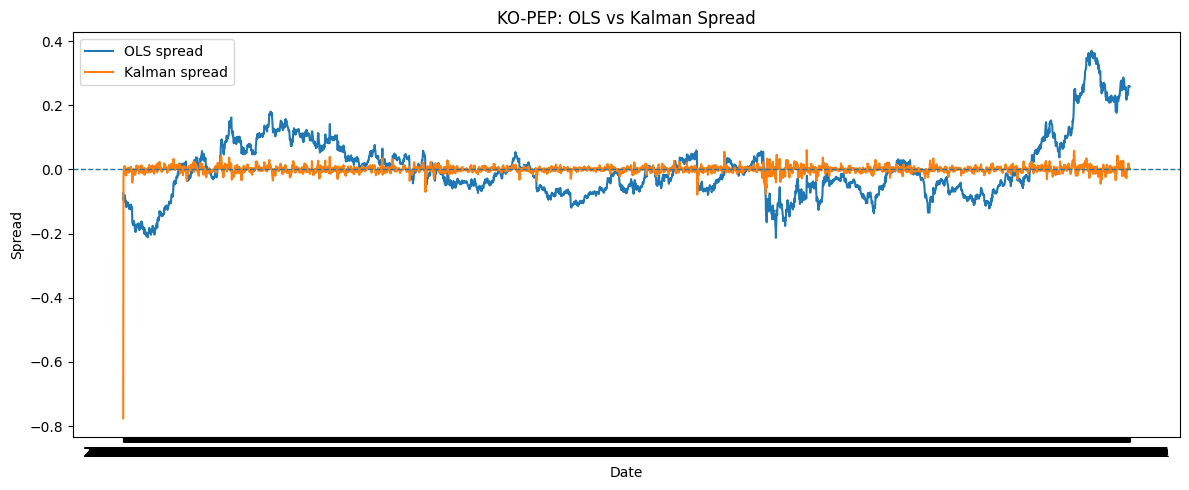

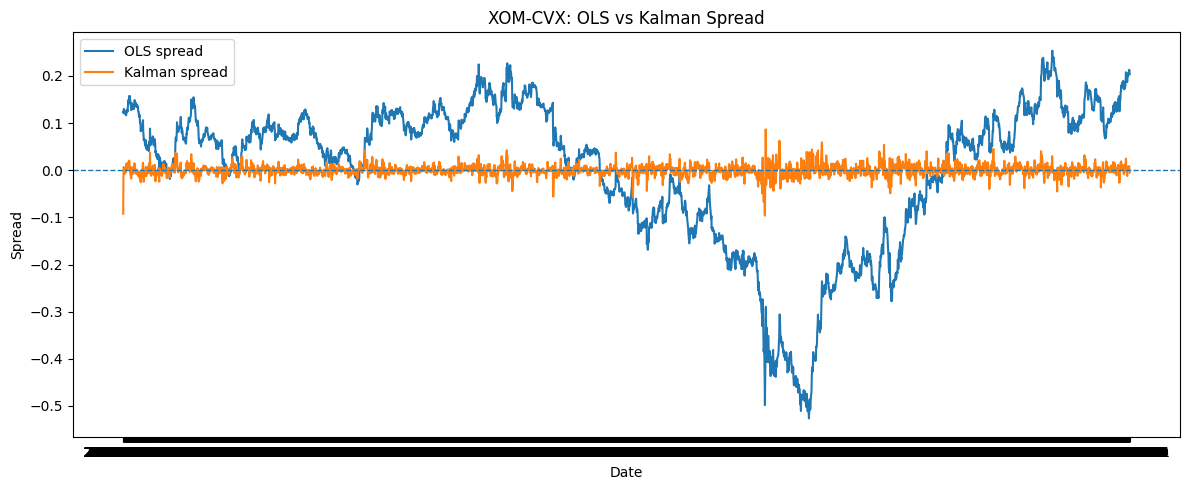

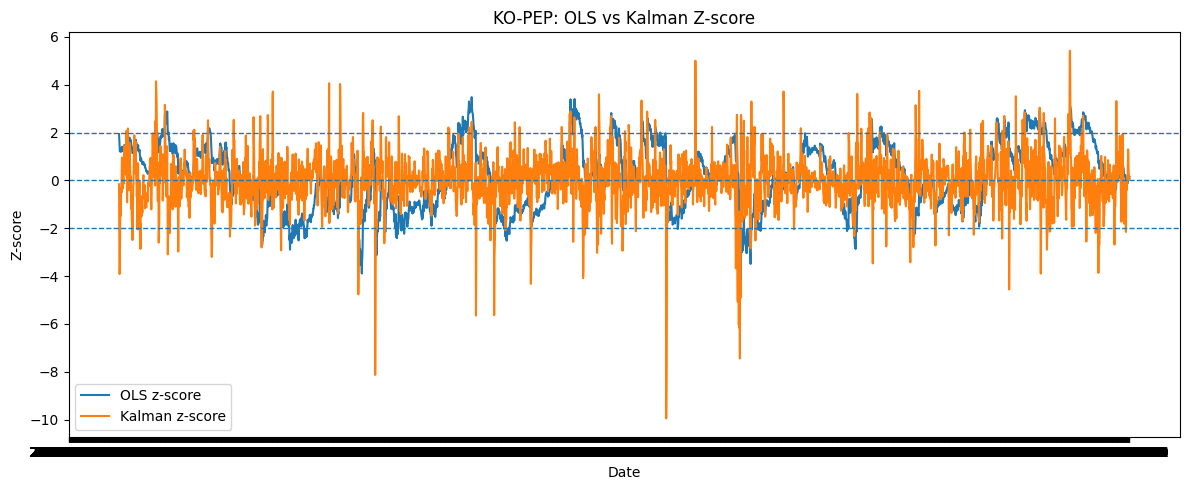

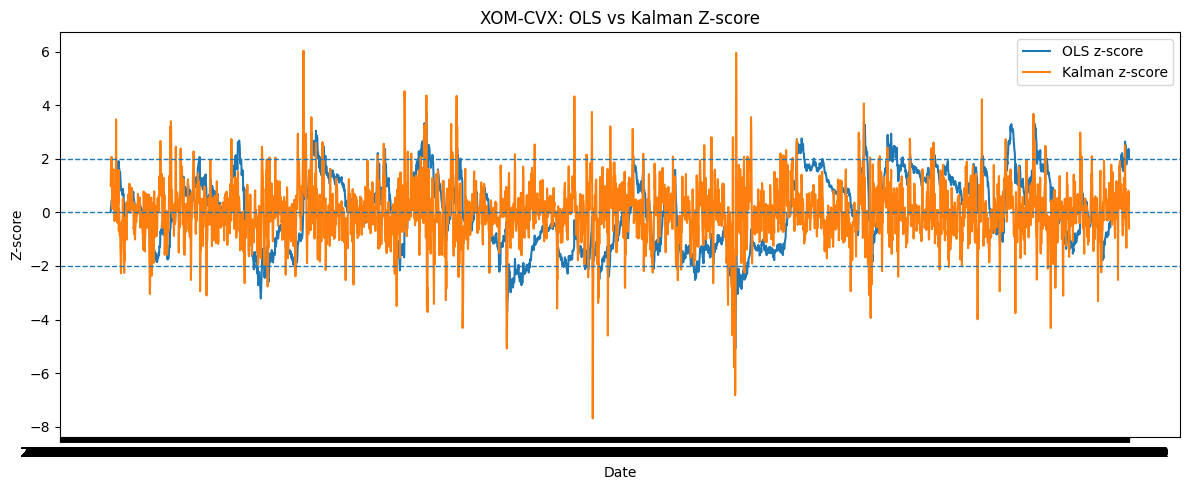

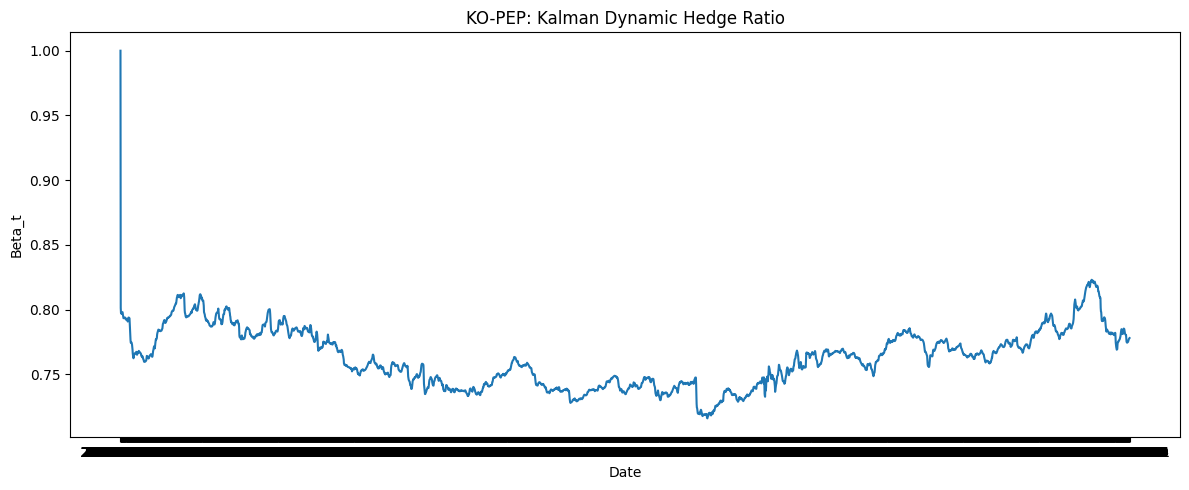

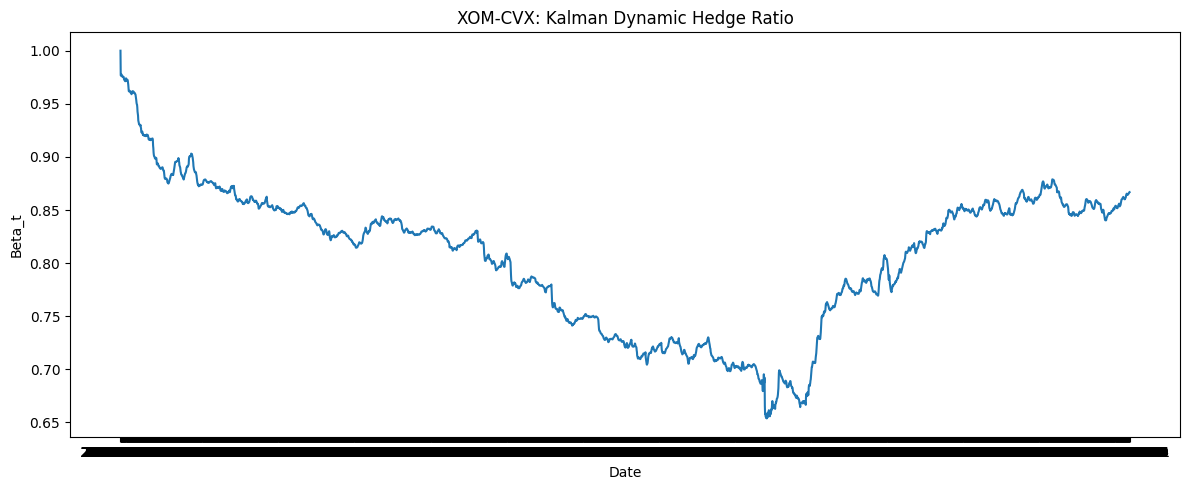

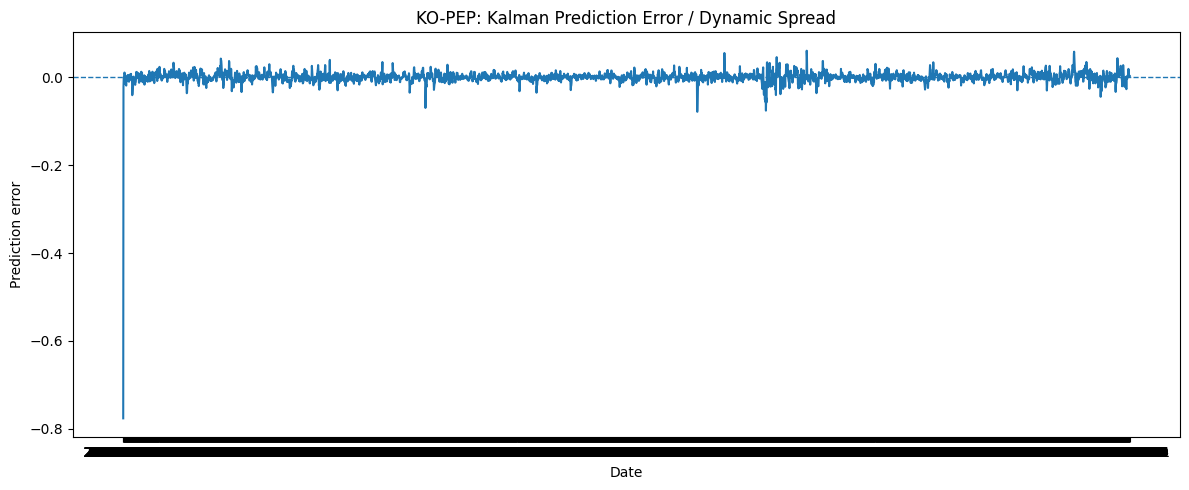

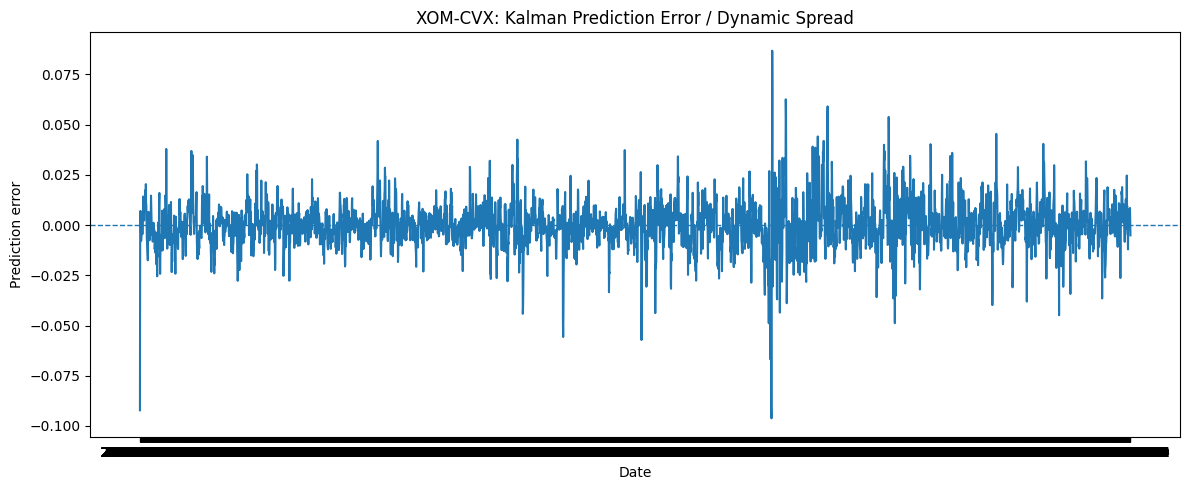

In [26]:
plot_spread(
    "KO-PEP",
    spread_ols_ko_pep,
    spread_kf_ko_pep
)

plot_spread(
    "XOM-CVX",
    spread_ols_xom_cvx,
    spread_kf_xom_cvx
)

plot_zscore(
    "KO-PEP",
    zscore_ols_ko_pep,
    zscore_kf_ko_pep
)

plot_zscore(
    "XOM-CVX",
    zscore_ols_xom_cvx,
    zscore_kf_xom_cvx
)

plot_kalman_beta(
    "KO-PEP",
    beta_kf_ko_pep
)

plot_kalman_beta(
    "XOM-CVX",
    beta_kf_xom_cvx
)

plot_prediction_error(
    "KO-PEP",
    spread_kf_ko_pep
)

plot_prediction_error(
    "XOM-CVX",
    spread_kf_xom_cvx
)

# out of sample spread validation
Does spread remain stable in future regimes? (If we estimate OLS on the past, does it still work in the future?)

Train OLS beta on train period

Apply fixed beta to validation/test periods

Compute spread stability metrics

Save table + plots

In [27]:
from statsmodels.tsa.stattools import adfuller

OUTPUT_DIR = DATA_DIR + "/validation_outputs/oos_validation_outputs"
FIG_DIR = OUTPUT_DIR + "/figures"


In [28]:
def adf_stat_pvalue(series):
    s = series.dropna()
    if len(s) < 30:
        return np.nan, np.nan
    result = adfuller(s)
    return result[0], result[1]


def spread_metrics(pair, model, period, spread):
    adf_stat, adf_p = adf_stat_pvalue(spread)

    return {
        "pair": pair,
        "model": model,
        "period": period,
        "spread_mean": spread.mean(),
        "spread_std": spread.std(),
        "spread_iqr": spread.quantile(0.75) - spread.quantile(0.25),
        "half_life": series_half_life(spread),
        "ADF_stat": adf_stat,
        "ADF_pvalue": adf_p,
        "n_obs": spread.dropna().shape[0]
    }

In [29]:
# OLS OOS
def fit_static_ols(y_train, x_train):
    X = np.column_stack([np.ones(len(x_train)), x_train.values])
    Y = y_train.values
    alpha, beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    return alpha, beta


def static_ols_oos_validation(
    pair,
    y,
    x,
    train_start="2010-01-01",
    train_end="2020-12-31",
    val_start="2021-01-01",
    val_end="2023-12-31",
    test_start="2024-01-01",
    test_end="2025-12-31"
):
    y = y.copy()
    x = x.copy()
    y.index = pd.to_datetime(y.index)
    x.index = pd.to_datetime(x.index)

    y_train, x_train = y.loc[train_start:train_end], x.loc[train_start:train_end]
    y_val, x_val = y.loc[val_start:val_end], x.loc[val_start:val_end]
    y_test, x_test = y.loc[test_start:test_end], x.loc[test_start:test_end]

    alpha, beta = fit_static_ols(y_train, x_train)

    spread_train = y_train - (alpha + beta * x_train)
    spread_val = y_val - (alpha + beta * x_val)
    spread_test = y_test - (alpha + beta * x_test)

    table = pd.DataFrame([
        spread_metrics(pair, "Static OLS", "train", spread_train),
        spread_metrics(pair, "Static OLS", "validation", spread_val),
        spread_metrics(pair, "Static OLS", "test", spread_test)
    ])

    table["OLS_alpha_train"] = alpha
    table["OLS_beta_train"] = beta

    return table, spread_train, spread_val, spread_test

In [30]:
ols_ko, ols_ko_train, ols_ko_val, ols_ko_test = static_ols_oos_validation(
    "KO-PEP",
    KO_log_prices["KO"],
    PEP_log_prices["PEP"]
)

ols_xom, ols_xom_train, ols_xom_val, ols_xom_test = static_ols_oos_validation(
    "XOM-CVX",
    XOM_log_prices["XOM"],
    CVX_log_prices["CVX"]
)

In [31]:
#kalman OOS

# def kalman_one_step_spread(y, x, q=1e-4, r=1e-2):
#     alpha = pd.Series(index=y.index, dtype=float)
#     beta = pd.Series(index=y.index, dtype=float)
#     spread = pd.Series(index=y.index, dtype=float)

#     state_mean = np.array([0.0, 1.0])
#     state_cov = np.eye(2)

#     for i in range(len(y)):
#         obs_matrix = np.array([[1.0, x.iloc[i]]])

#         # one-step prediction before observing today's y
#         state_mean_pred = state_mean
#         state_cov_pred = state_cov + q * np.eye(2)

#         alpha.iloc[i] = state_mean_pred[0]
#         beta.iloc[i] = state_mean_pred[1]
#         spread.iloc[i] = y.iloc[i] - (alpha.iloc[i] + beta.iloc[i] * x.iloc[i])

#         # update after observing today's y
#         y_pred = (obs_matrix @ state_mean_pred).item()
#         innovation = y.iloc[i] - y_pred
#         S = (obs_matrix @ state_cov_pred @ obs_matrix.T).item() + r
#         K = state_cov_pred @ obs_matrix.T / S

#         state_mean = state_mean_pred + K.flatten() * innovation
#         state_cov = state_cov_pred - K @ obs_matrix @ state_cov_pred

#     return spread, alpha, beta


def kalman_oos_validation_from_existing(
    pair,
    spread_kf,
    beta_kf,
    alpha_kf,
    train_start="2010-01-01",
    train_end="2020-12-31",
    val_start="2021-01-01",
    val_end="2023-12-31",
    test_start="2024-01-01",
    test_end="2025-12-31"
):
    spread_kf.index = pd.to_datetime(spread_kf.index)
    beta_kf.index = pd.to_datetime(beta_kf.index)
    alpha_kf.index = pd.to_datetime(alpha_kf.index)

    spread_train = spread_kf.loc[train_start:train_end]
    spread_val = spread_kf.loc[val_start:val_end]
    spread_test = spread_kf.loc[test_start:test_end]

    table = pd.DataFrame([
        spread_metrics(pair, "Kalman", "train", spread_train),
        spread_metrics(pair, "Kalman", "validation", spread_val),
        spread_metrics(pair, "Kalman", "test", spread_test)
    ])

    table["Kalman_alpha_mean"] = alpha_kf.mean()
    table["Kalman_beta_mean"] = beta_kf.mean()
    table["Kalman_beta_std"] = beta_kf.std()
    table["Kalman_beta_min"] = beta_kf.min()
    table["Kalman_beta_max"] = beta_kf.max()

    return table, spread_train, spread_val, spread_test

In [32]:
kf_ko_oos, kf_ko_train, kf_ko_val, kf_ko_test = kalman_oos_validation_from_existing(
    "KO-PEP",
    spread_kf_ko_pep,
    beta_kf_ko_pep,
    alpha_kf_ko_pep
)

kf_xom_oos, kf_xom_train, kf_xom_val, kf_xom_test = kalman_oos_validation_from_existing(
    "XOM-CVX",
    spread_kf_xom_cvx,
    beta_kf_xom_cvx,
    alpha_kf_xom_cvx
)

In [33]:
oos_validation_table = pd.concat(
    [ols_ko, ols_xom, kf_ko_oos, kf_xom_oos],
    axis=0,
    ignore_index=True
)

oos_validation_table.to_csv(
    OUTPUT_DIR  + "/oos_spread_validation_table.csv",
    index=False
)

oos_validation_table

,pair,model,period,spread_mean,spread_std,spread_iqr,half_life,ADF_stat,ADF_pvalue,n_obs,OLS_alpha_train,OLS_beta_train,Kalman_alpha_mean,Kalman_beta_mean,Kalman_beta_std,Kalman_beta_min,Kalman_beta_max
0,KO-PEP,Static OLS,train,4.888349e-16,0.071660,0.085571,107.369843,-2.938345,4.106723e-02,2769,0.303312,0.729728,NaN,NaN,NaN,NaN,NaN
1,KO-PEP,Static OLS,validation,1.014776e-02,0.036782,0.045236,45.718551,-3.141238,2.364810e-02,753,0.303312,0.729728,NaN,NaN,NaN,NaN,NaN
2,KO-PEP,Static OLS,test,2.068712e-01,0.119092,0.185594,166.476066,-1.294373,6.317427e-01,502,0.303312,0.729728,NaN,NaN,NaN,NaN,NaN
3,XOM-CVX,Static OLS,train,-1.021293e-15,0.146797,0.131724,1589.225520,-0.219375,9.361724e-01,2769,1.467369,0.579661,NaN,NaN,NaN,NaN,NaN
4,XOM-CVX,Static OLS,validation,5.124329e-02,0.182901,0.356401,129.922367,-2.115786,2.382146e-01,753,1.467369,0.579661,NaN,NaN,NaN,NaN,NaN
5,XOM-CVX,Static OLS,test,3.307154e-01,0.046219,0.057299,38.445245,-2.202447,2.053585e-01,502,1.467369,0.579661,NaN,NaN,NaN,NaN,NaN
6,KO-PEP,Kalman,train,-1.851299e-04,0.017959,0.009865,0.893951,-14.495635,6.047566e-27,2769,NaN,NaN,0.184089,0.763005,0.022442,0.716011,1.0
7,KO-PEP,Kalman,validation,-3.825272e-06,0.008092,0.009102,1.794775,-8.190009,7.713241e-13,753,NaN,NaN,0.184089,0.763005,0.022442,0.716011,1.0
8,KO-PEP,Kalman,test,1.542969e-03,0.011686,0.013492,1.975342,-10.304201,3.311529e-18,502,NaN,NaN,0.184089,0.763005,0.022442,0.716011,1.0
9,XOM-CVX,Kalman,train,-5.816017e-04,0.011066,0.010852,1.779404,-13.773788,9.573733e-26,2769,NaN,NaN,0.524640,0.805750,0.065989,0.653816,1.0


In [34]:
def plot_oos_spread_comparison(
    pair,
    ols_train,
    ols_val,
    ols_test,
    kf_train,
    kf_val,
    kf_test,
    train_end="2020-12-31",
    val_end="2023-12-31"
):
    ols_spread = pd.concat([ols_train, ols_val, ols_test])
    kf_spread = pd.concat([kf_train, kf_val, kf_test])

    plt.figure(figsize=(12, 5))

    plt.plot(ols_spread.index, ols_spread, label="Static OLS spread")
    plt.plot(kf_spread.index, kf_spread, label="Kalman spread")

    plt.axhline(0, linestyle="--", linewidth=1)

    # split lines
    plt.axvline(pd.to_datetime(train_end), linestyle="--", linewidth=1, color="red",label="Train/Val split")
    plt.axvline(pd.to_datetime(val_end), linestyle="--", linewidth=1, color = "green", label="Val/Test split")

    plt.title(f"{pair}: OOS Spread Validation")
    plt.xlabel("Date")
    plt.ylabel("Spread")
    plt.legend()
    plt.tight_layout()

    plt.savefig(FIG_DIR + f"/{pair}_oos_spread_validation.png", dpi=300)
    plt.show()

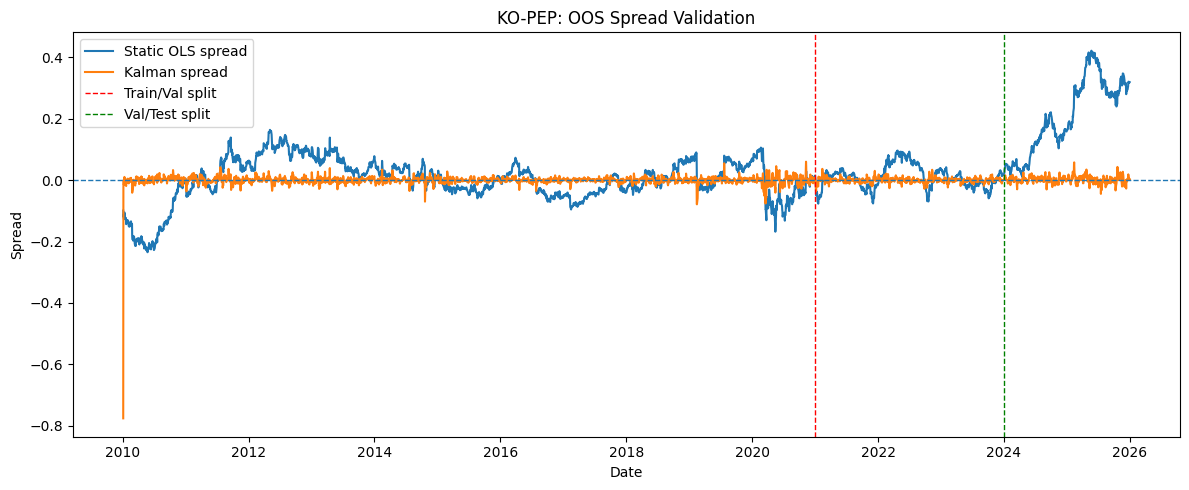

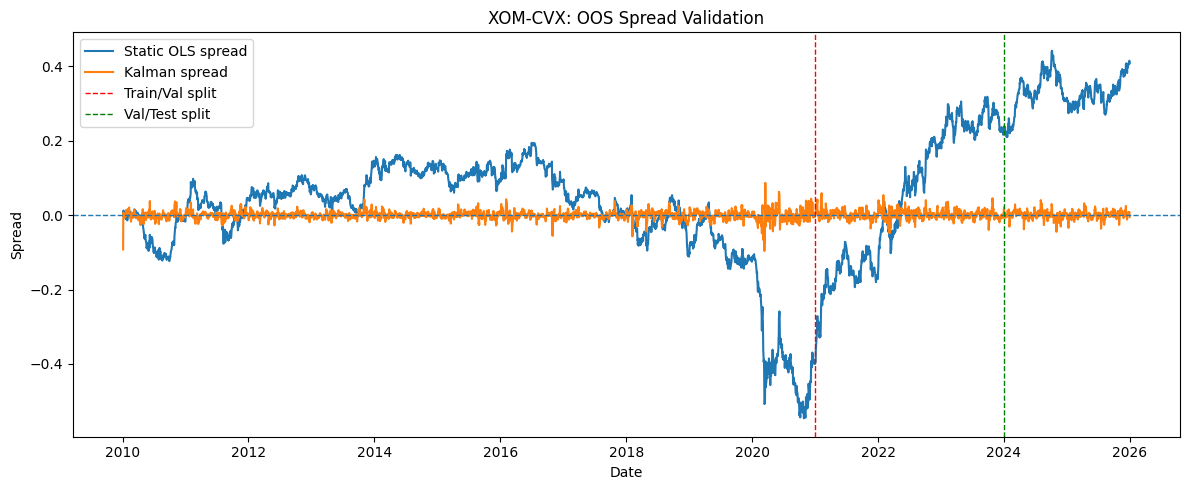

In [35]:
plot_oos_spread_comparison(
    "KO-PEP",
    ols_ko_train,
    ols_ko_val,
    ols_ko_test,
    kf_ko_train,
    kf_ko_val,
    kf_ko_test,
    train_end="2020-12-31",
    val_end="2023-12-31"
)

plot_oos_spread_comparison(
    "XOM-CVX",
    ols_xom_train,
    ols_xom_val,
    ols_xom_test,
    kf_xom_train,
    kf_xom_val,
    kf_xom_test,
    train_end="2020-12-31",
    val_end="2023-12-31"
)

In [36]:
OUTPUT_DIR = DATA_DIR + "/output"
backtest_input.to_csv(OUTPUT_DIR + "/backtest_input_with_kalman.csv", index=False)


ML logic:
用今天的 features 预测这个 z-score entry signal 未来会不会成功 mean-revert, 即这个trade值不值得做

ML 判断当 z-score 已经触发 entry 时，判断要不要进场

Feature = 今天看到的 spread 状态

Label = 未来几天这个 signal 有没有成功回归



# rolling ML features and labels

## create ML lables
edit in report:

For a long-spread signal, label = 1 if the spread increases over the next h days.

For a short-spread signal, label = 1 if the spread decreases over the next h days.

In [59]:
#features 
def calculate_rolling_features(
    spread,
    zscore,
    log_returns_y,
    log_returns_x,
    beta=None,
    window=20,
    adf_window=60
):
    from statsmodels.tsa.stattools import adfuller

    spread = pd.Series(spread).astype(float)
    zscore = pd.Series(zscore).reindex(spread.index).astype(float)

    # Align returns with spread index
    log_returns_y = pd.Series(log_returns_y).reindex(spread.index).astype(float)
    log_returns_x = pd.Series(log_returns_x).reindex(spread.index).astype(float)

    features = pd.DataFrame(index=spread.index)

    # Current signal state
    features["spread"] = spread
    features["zscore"] = zscore
    features["abs_zscore"] = zscore.abs()

    # Beta features
    if beta is not None:
        if np.isscalar(beta):
            beta = pd.Series(beta, index=spread.index, dtype=float)
        else:
            beta = pd.Series(beta).reindex(spread.index).ffill().astype(float)

        features["beta"] = beta
        features["delta_beta"] = beta.diff()
        features["abs_delta_beta"] = features["delta_beta"].abs()

    # Z-score lags and momentum
    features["zscore_lag1"] = zscore.shift(1)
    features["zscore_lag3"] = zscore.shift(3)
    features["zscore_lag5"] = zscore.shift(5)
    features["delta_zscore"] = zscore.diff()

    # Use previous window to avoid same-day rolling-stat leakage
    spread_hist = spread.shift(1)
    ret_y_hist = log_returns_y.shift(1)
    ret_x_hist = log_returns_x.shift(1)

    features["spread_volatility"] = spread_hist.rolling(
        window, min_periods=int(window * 0.8)
    ).std()

    features["spread_autocorr"] = spread_hist.rolling(
        window, min_periods=int(window * 0.8)
    ).apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)

    features["return_correlation"] = ret_y_hist.rolling(
        window, min_periods=int(window * 0.8)
    ).corr(ret_x_hist)

    def rolling_adf_pvalue(series, window=60):
        pvals = pd.Series(index=series.index, dtype=float)
        s = series.astype(float)

        for i in range(window, len(s)):
            w = s.iloc[i-window:i].dropna()

            if len(w) < window * 0.9:
                continue
            if w.nunique() < 3:
                continue

            try:
                pvals.iloc[i] = adfuller(
                    w.values,
                    maxlag=1,
                    regression="c",
                    autolag=None
                )[1]
            except Exception:
                pvals.iloc[i] = np.nan

        return pvals

    features["adf_pvalue"] = rolling_adf_pvalue(spread, window=adf_window)

    return features

In [60]:
features_ols_ko_pep = calculate_rolling_features(
    spread_ols_ko_pep,
    zscore_ols_ko_pep,
    KO_log_returns["KO"],
    PEP_log_returns["PEP"],
    beta=beta_ols_ko_pep,
)

features_kf_ko_pep = calculate_rolling_features(
    spread_kf_ko_pep,
    zscore_kf_ko_pep,
    KO_log_returns["KO"],
    PEP_log_returns["PEP"],
    beta=beta_kf_ko_pep,
)

In [115]:
features_kf_ko_pep.head()

,spread,zscore,abs_zscore,beta,delta_beta,abs_delta_beta,zscore_lag1,zscore_lag3,zscore_lag5,delta_zscore,spread_volatility,spread_autocorr,return_correlation,adf_pvalue
Date,,,,,,,,,,,,,,
2010-01-04,-0.776058,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,-0.022343,NaN,NaN,0.801323,-0.198677,0.198677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,-0.002736,NaN,NaN,0.797392,-0.003930,0.003930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,0.000960,NaN,NaN,0.797162,-0.000231,0.000231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,-0.015441,NaN,NaN,0.797209,0.000047,0.000047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
features_ols_xom_cvx = calculate_rolling_features(
    spread_ols_xom_cvx,
    zscore_ols_xom_cvx,
    XOM_log_returns["XOM"],
    CVX_log_returns["CVX"],
    beta=beta_ols_xom_cvx,
)

features_kf_xom_cvx = calculate_rolling_features(
    spread_kf_xom_cvx,
    zscore_kf_xom_cvx,
    XOM_log_returns["XOM"],
    CVX_log_returns["CVX"],
    beta=beta_kf_xom_cvx,
)

In [118]:
features_kf_xom_cvx.shape

(4024, 14)

# Labels

We define the ML label only on z-score entry dates. A signal is labeled successful if the spread reaches the exit region, |z| <= 0.5, within the next 10 trading days. This makes the classification target directly aligned with the trading rule used in S3 and S4.

In [ ]:
# def create_entry_mean_reversion_labels(
#     zscore,
#     horizon=10,
#     entry_threshold=2.0,
#     min_improvement=0.0
# ):
#     """
#     Binary label for ML entry filter.

#     Label is defined only on entry-signal days:
#         |z_t| >= entry_threshold

#     Y_t = 1 if the spread moves closer to mean after horizon days:
#         |z_{t+h}| < |z_t|

#     Optional min_improvement prevents tiny changes from counting as success.

#     label = 1 if abs(zscore_t_plus_10) < abs(zscore_t) else 0
#     """

#     z = zscore.astype(float)
#     labels = pd.Series(index=z.index, dtype=float)

#     current_abs_z = z.abs()
#     future_abs_z = z.shift(-horizon).abs()

#     entry_signal = current_abs_z >= entry_threshold
#     valid = entry_signal & current_abs_z.notna() & future_abs_z.notna()

#     improvement = current_abs_z - future_abs_z

#     labels.loc[valid] = (improvement.loc[valid] > min_improvement).astype(float)

#     return labels

In [ ]:
# def create_entry_mean_reversion_labels(
#     zscore,
#     horizon=10,
#     entry_threshold=2.0,
#     min_improvement=0.25
# ):
#     """
#     Label only entry-signal days.

#     Label = 1 if |z| decreases by at least min_improvement.
#     Label = 0 if |z| does not improve.
#     Weak improvements are treated as NaN to avoid noisy labels.
#     """

#     z = zscore.astype(float)
#     labels = pd.Series(index=z.index, dtype=float)

#     current_abs_z = z.abs()
#     future_abs_z = z.shift(-horizon).abs()

#     entry_signal = current_abs_z >= entry_threshold
#     valid = entry_signal & current_abs_z.notna() & future_abs_z.notna()

#     improvement = current_abs_z - future_abs_z

#     # Strong mean reversion
#     labels.loc[valid & (improvement >= min_improvement)] = 1.0

#     # No improvement or worsening
#     labels.loc[valid & (improvement <= 0)] = 0.0

#     # Weak improvement between 0 and min_improvement stays NaN

#     return labels

In [ ]:
# for m in [0.0, 0.10, 0.25, 0.50, 0.75]:
#     lab = create_entry_mean_reversion_labels(
#         zscore_ols_ko_pep,
#         horizon=10,
#         entry_threshold=2.0,
#         min_improvement=m
#     )
#     print(f"min_improvement={m}")
#     print(lab.value_counts(dropna=True))
#     print("positive ratio:", lab.mean())
#     print()

min_improvement=0.0
1.0    400
0.0    131
Name: count, dtype: int64
positive ratio: 0.7532956685499058

min_improvement=0.1
1.0    371
0.0    131
Name: count, dtype: int64
positive ratio: 0.7390438247011952

min_improvement=0.25
1.0    319
0.0    131
Name: count, dtype: int64
positive ratio: 0.7088888888888889

min_improvement=0.5
1.0    199
0.0    131
Name: count, dtype: int64
positive ratio: 0.603030303030303

min_improvement=0.75
1.0    136
0.0    131
Name: count, dtype: int64
positive ratio: 0.5093632958801498



In [ ]:
# def create_percentage_improvement_labels(
#     zscore,
#     horizon=10,
#     entry_threshold=2.0,
#     min_pct_improvement=0.10
# ):
#     """
#     Label = 1 if |z| shrinks by at least min_pct_improvement.
#     Example: 10% improvement means |z_future| <= 0.90 * |z_current|.
#     """

#     z = zscore.astype(float)
#     labels = pd.Series(index=z.index, dtype=float)

#     current_abs_z = z.abs()
#     future_abs_z = z.shift(-horizon).abs()

#     entry_signal = current_abs_z >= entry_threshold
#     valid = entry_signal & current_abs_z.notna() & future_abs_z.notna()

#     pct_improvement = (current_abs_z - future_abs_z) / current_abs_z

#     labels.loc[valid & (pct_improvement >= min_pct_improvement)] = 1.0
#     labels.loc[valid & (pct_improvement <= 0)] = 0.0

#     return labels

In [ ]:
# for p in [0.05, 0.10, 0.15, 0.20]:
#     lab = create_percentage_improvement_labels(
#         zscore_ols_ko_pep,
#         horizon=10,
#         entry_threshold=2.0,
#         min_pct_improvement=p
#     )
#     print(f"min_pct_improvement={p}")
#     print(lab.value_counts(dropna=True))
#     print("positive ratio:", lab.mean())
#     print()

min_pct_improvement=0.05
1.0    369
0.0    131
Name: count, dtype: int64
positive ratio: 0.738

min_pct_improvement=0.1
1.0    318
0.0    131
Name: count, dtype: int64
positive ratio: 0.7082405345211581

min_pct_improvement=0.15
1.0    266
0.0    131
Name: count, dtype: int64
positive ratio: 0.6700251889168766

min_pct_improvement=0.2
1.0    214
0.0    131
Name: count, dtype: int64
positive ratio: 0.6202898550724638



In [ ]:
# labels_ols_ko_pep = create_entry_mean_reversion_labels(zscore_ols_ko_pep, horizon=10)
# labels_kf_ko_pep = create_entry_mean_reversion_labels(zscore_kf_ko_pep, horizon=10)
# labels_ols_xom_cvx = create_entry_mean_reversion_labels(zscore_ols_xom_cvx, horizon=10)
# labels_kf_xom_cvx = create_entry_mean_reversion_labels(zscore_kf_xom_cvx, horizon=10)

In [ ]:
# print(labels_ols_ko_pep.value_counts(dropna=False))
# print("Positive ratio:", labels_ols_ko_pep.mean())

NaN    3574
1.0     319
0.0     131
Name: count, dtype: int64
Positive ratio: 0.7088888888888889


In [ ]:
# def create_directional_trade_labels(
#     zscore,
#     horizon=10,
#     entry_threshold=2.0,
#     min_z_move=0.25
# ):
#     """
#     Direction-aware trade label.

#     For z > 2:
#         successful if z_t - z_{t+h} >= min_z_move

#     For z < -2:
#         successful if z_{t+h} - z_t >= min_z_move
#     """

#     z = zscore.astype(float)
#     labels = pd.Series(index=z.index, dtype=float)

#     future_z = z.shift(-horizon)

#     valid = z.notna() & future_z.notna() & (z.abs() >= entry_threshold)

#     directional_move = -np.sign(z) * (future_z - z)

#     labels.loc[valid & (directional_move >= min_z_move)] = 1.0
#     labels.loc[valid & (directional_move <= 0)] = 0.0

#     return labels

In [ ]:
# for m in [0.05, 0.10, 0.15, 0.20, 0.25, 0.50, 0.75, 1.00]:
#     lab = create_directional_trade_labels(
#         zscore_ols_ko_pep,
#         horizon=10,
#         entry_threshold=2.0,
#         min_z_move=m
#     )

#     print(f"min_z_move={m}")
#     print(lab.value_counts(dropna=True))
#     print("positive ratio:", lab.dropna().mean())
#     print("labeled samples:", lab.notna().sum())
#     print()

min_z_move=0.05
1.0    387
0.0    131
Name: count, dtype: int64
positive ratio: 0.747104247104247
labeled samples: 518

min_z_move=0.1
1.0    371
0.0    131
Name: count, dtype: int64
positive ratio: 0.7390438247011952
labeled samples: 502

min_z_move=0.15
1.0    357
0.0    131
Name: count, dtype: int64
positive ratio: 0.7315573770491803
labeled samples: 488

min_z_move=0.2
1.0    336
0.0    131
Name: count, dtype: int64
positive ratio: 0.7194860813704497
labeled samples: 467

min_z_move=0.25
1.0    319
0.0    131
Name: count, dtype: int64
positive ratio: 0.7088888888888889
labeled samples: 450

min_z_move=0.5
1.0    199
0.0    131
Name: count, dtype: int64
positive ratio: 0.603030303030303
labeled samples: 330

min_z_move=0.75
1.0    136
0.0    131
Name: count, dtype: int64
positive ratio: 0.5093632958801498
labeled samples: 267

min_z_move=1.0
0.0    131
1.0     78
Name: count, dtype: int64
positive ratio: 0.37320574162679426
labeled samples: 209



In [ ]:
# def create_directional_trade_labels(
#     zscore,
#     horizon=10,
#     entry_threshold=2.0,
#     min_z_move=0.25
# ):
#     """
#     Direction-aware trade label.

#     Label only entry-signal days:
#         |z_t| >= entry_threshold

#     For z_t > 2:
#         success if z_t - z_{t+h} >= min_z_move

#     For z_t < -2:
#         success if z_{t+h} - z_t >= min_z_move

#     Weak moves are treated as unsuccessful.
#     """

#     z = zscore.astype(float)
#     labels = pd.Series(index=z.index, dtype=float)

#     future_z = z.shift(-horizon)

#     valid = z.notna() & future_z.notna() & (z.abs() >= entry_threshold)

#     directional_move = -np.sign(z) * (future_z - z)

#     labels.loc[valid] = (directional_move.loc[valid] >= min_z_move).astype(float)

#     return labels

In [ ]:
# for m in [0.05, 0.10, 0.15, 0.20, 0.25, 0.50, 0.75, 1.00]:
#     lab = create_directional_trade_labels(
#         zscore_ols_ko_pep,
#         horizon=10,
#         entry_threshold=2.0,
#         min_z_move=m
#     )

#     print(f"min_z_move={m}")
#     print(lab.value_counts(dropna=True))
#     print("positive ratio:", lab.dropna().mean())
#     print("labeled samples:", lab.notna().sum())
#     print()

min_z_move=0.05
1.0    387
0.0    144
Name: count, dtype: int64
positive ratio: 0.7288135593220338
labeled samples: 531

min_z_move=0.1
1.0    371
0.0    160
Name: count, dtype: int64
positive ratio: 0.6986817325800376
labeled samples: 531

min_z_move=0.15
1.0    357
0.0    174
Name: count, dtype: int64
positive ratio: 0.672316384180791
labeled samples: 531

min_z_move=0.2
1.0    336
0.0    195
Name: count, dtype: int64
positive ratio: 0.632768361581921
labeled samples: 531

min_z_move=0.25
1.0    319
0.0    212
Name: count, dtype: int64
positive ratio: 0.60075329566855
labeled samples: 531

min_z_move=0.5
0.0    332
1.0    199
Name: count, dtype: int64
positive ratio: 0.3747645951035782
labeled samples: 531

min_z_move=0.75
0.0    395
1.0    136
Name: count, dtype: int64
positive ratio: 0.256120527306968
labeled samples: 531

min_z_move=1.0
0.0    453
1.0     78
Name: count, dtype: int64
positive ratio: 0.14689265536723164
labeled samples: 531



choose min_z_move = 0.20

In [ ]:
# labels_ols_ko_pep = create_directional_trade_labels(zscore_ols_ko_pep)
# labels_kf_ko_pep = create_directional_trade_labels(zscore_kf_ko_pep)
# labels_ols_xom_cvx = create_directional_trade_labels(zscore_ols_xom_cvx)
# labels_kf_xom_cvx = create_directional_trade_labels(zscore_kf_xom_cvx)

# for name, lab in {
#     "OLS KO-PEP": labels_ols_ko_pep,
#     "KF KO-PEP": labels_kf_ko_pep,
#     "OLS XOM-CVX": labels_ols_xom_cvx,
#     "KF XOM-CVX": labels_kf_xom_cvx,
# }.items():
#     print(name)
#     print(lab.value_counts(dropna=True))
#     print("positive ratio:", lab.dropna().mean())
#     print("labeled samples:", lab.notna().sum())
#     print()

OLS KO-PEP
1.0    319
0.0    212
Name: count, dtype: int64
positive ratio: 0.60075329566855
labeled samples: 531

KF KO-PEP
1.0    225
0.0      9
Name: count, dtype: int64
positive ratio: 0.9615384615384616
labeled samples: 234

OLS XOM-CVX
1.0    283
0.0    210
Name: count, dtype: int64
positive ratio: 0.5740365111561866
labeled samples: 493

KF XOM-CVX
1.0    194
0.0      8
Name: count, dtype: int64
positive ratio: 0.9603960396039604
labeled samples: 202



The issue is that min_z_move=0.20 is too easy for Kalman z-scores. Kalman spread adapts quickly, so most entry signals naturally move in the mean-reversion direction by at least 0.20.

label is still a bit biased, for adaboost, train with balanced sample weights

In [ ]:
# def create_directional_trade_labels(
#     zscore,
#     horizon=10,
#     entry_threshold=2.0,
#     min_z_move=0.20,
#     min_pct_move=0.20,
#     event_only=False
# ):
#     """
#     Direction-aware trade label for ML entry filtering.

#     Label is defined only on entry-signal days:
#         |z_t| >= entry_threshold

#     For z_t > 2:
#         success if z_t - z_{t+h} is large enough

#     For z_t < -2:
#         success if z_{t+h} - z_t is large enough

#     Required move is:
#         max(min_z_move, min_pct_move * |z_t|)

#     This avoids making the label too easy when the z-score is large.
#     """

#     z = zscore.astype(float)
#     labels = pd.Series(index=z.index, dtype=float)

#     future_z = z.shift(-horizon)
#     abs_z = z.abs()

#     valid = z.notna() & future_z.notna() & (abs_z >= entry_threshold)

#     if event_only:
#         entry_event = (abs_z >= entry_threshold) & (abs_z.shift(1).fillna(0) < entry_threshold)
#         valid = valid & entry_event

#     directional_move = -np.sign(z) * (future_z - z)

#     required_move = np.maximum(
#         min_z_move,
#         min_pct_move * abs_z
#     )

#     labels.loc[valid] = (
#         directional_move.loc[valid] >= required_move.loc[valid]
#     ).astype(float)

#     return labels

In [ ]:
# zscore_dict = {
#     "OLS KO-PEP": zscore_ols_ko_pep,
#     "KF KO-PEP": zscore_kf_ko_pep,
#     "OLS XOM-CVX": zscore_ols_xom_cvx,
#     "KF XOM-CVX": zscore_kf_xom_cvx,
# }

# for pct in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
#     print("=" * 50)
#     print(f"min_pct_move={pct}")

#     for name, z in zscore_dict.items():
#         lab = create_directional_trade_labels(
#             z,
#             horizon=10,
#             entry_threshold=2.0,
#             min_z_move=0.20,
#             min_pct_move=pct,
#             event_only=False
#         )

#         print(name)
#         print(lab.value_counts(dropna=True))
#         print("positive ratio:", lab.dropna().mean())
#         print("labeled samples:", lab.notna().sum())
#         print()

min_pct_move=0.1
OLS KO-PEP
1.0    318
0.0    213
Name: count, dtype: int64
positive ratio: 0.5988700564971752
labeled samples: 531

KF KO-PEP
1.0    225
0.0      9
Name: count, dtype: int64
positive ratio: 0.9615384615384616
labeled samples: 234

OLS XOM-CVX
1.0    289
0.0    204
Name: count, dtype: int64
positive ratio: 0.5862068965517241
labeled samples: 493

KF XOM-CVX
1.0    194
0.0      8
Name: count, dtype: int64
positive ratio: 0.9603960396039604
labeled samples: 202

min_pct_move=0.15
OLS KO-PEP
1.0    266
0.0    265
Name: count, dtype: int64
positive ratio: 0.5009416195856874
labeled samples: 531

KF KO-PEP
1.0    224
0.0     10
Name: count, dtype: int64
positive ratio: 0.9572649572649573
labeled samples: 234

OLS XOM-CVX
0.0    247
1.0    246
Name: count, dtype: int64
positive ratio: 0.49898580121703856
labeled samples: 493

KF XOM-CVX
1.0    192
0.0     10
Name: count, dtype: int64
positive ratio: 0.9504950495049505
labeled samples: 202

min_pct_move=0.2
OLS KO-PEP
0.0    3

this label asks: Would the actual pair trade make money over the next 10 days?

Previous lables ask: Did the z-score move toward zero?

Since the label is very biased with kalman filter, likely because kalman's spread adapts quickly

### PnL-Based ML Label Construction

The purpose of the ML model is not to predict the exact future z-score. Instead, the model is used as a **trade filter**: when the traditional z-score rule gives an entry signal, the ML model predicts whether that signal is worth trading.

Therefore, labels are created only on entry-signal days:

$
|z_t| \geq 2
$

For days where \(|z_t| < 2\), no trade would be opened under the strategy, so the label is left as `NaN`.

---

### Trading Direction

The z-score determines the trade direction.

If:

$
z_t > 2
$

the spread is unusually high, so we expect it to fall. The strategy takes a **short-spread position**:

- short asset \(Y\)
- long \(\beta_t\) units of asset \(X\)

If:

$
z_t < -2
$

the spread is unusually low, so we expect it to rise. The strategy takes a **long-spread position**:

- long asset \(Y\)
- short \(\beta_t\) units of asset \(X\)

---

### Forward PnL Proxy

For each entry day \(t\), we compute the future spread return over the next \(h\) days:

$
R^{spread}_{t,t+h}
=
\sum_{i=1}^{h} r^Y_{t+i}
-
\beta_t
\sum_{i=1}^{h} r^X_{t+i}
$

where:

- \(r^Y\) is the log return of asset \(Y\)
- \(r^X\) is the log return of asset \(X\)
- \(\beta_t\) is the hedge ratio
- \(h = 10\) trading days in this project

The trade direction is determined by the sign of the z-score:

$
direction_t = -\text{sign}(z_t)
$

So the forward PnL proxy is:

$
PnL_{t,t+h}
=
-\text{sign}(z_t)
\left(
\sum_{i=1}^{h} r^Y_{t+i}
-
\beta_t
\sum_{i=1}^{h} r^X_{t+i}
\right)
$

This formula works for both long-spread and short-spread trades.

---

### Binary Label Definition

The ML label is defined as:

$
Y_t =
\begin{cases}
1, & \text{if } PnL_{t,t+h} > \text{min\_return} \\
0, & \text{otherwise}
\end{cases}
$

In the main experiment, we use:

$
h = 10
$

and:

$
\text{min\_return} = 0
$

So a signal is labeled `1` if the corresponding pair trade would have made a positive return over the next 10 trading days. Otherwise, it is labeled `0`.

---

### Interpretation

This label makes the ML model directly answer the trading question:

> Given a z-score entry signal today, would the corresponding pair trade have been profitable over the next 10 trading days?

This is more economically meaningful than simply asking whether the z-score moved closer to zero. A z-score may mean-revert mechanically, especially under the Kalman filter, but that does not always mean the actual trade produces positive return. By using a PnL-based label, the ML model becomes a true trade-timing filter.

---

### Why This Label Is Useful

This label has several advantages:

1. It is aligned with the actual trading rule.
2. It works for both OLS and Kalman spreads.
3. It accounts for the hedge ratio through $\beta_t$.
4. It avoids overly biased labels caused by Kalman z-score mean reversion.
5. It produces a more balanced classification problem.

After applying this label definition, the class distributions are reasonably balanced across both pairs and both spread-construction methods:

| Dataset | Positive Ratio |
|---|---:|
| OLS KO-PEP | 55.6% |
| Kalman KO-PEP | 53.0% |
| OLS XOM-CVX | 55.8% |
| Kalman XOM-CVX | 58.9% |

Therefore, the ML model has enough positive and negative examples to learn whether to approve or reject a z-score trading signal.

---

### Important Note on Look-Ahead Bias

The label uses future returns from \(t+1\) to \(t+h\), which is allowed because labels are the supervised-learning target. However, all features used to predict the label must be computed using only information available at or before time \(t\). This ensures that the model evaluation remains out-of-sample and avoids look-ahead bias.

In [109]:
def align_to_z_index(x, z_index, name=None):
    """
    Robustly align scalar / Series / array to z-score index.
    """

    if np.isscalar(x):
        return pd.Series(x, index=z_index, dtype=float, name=name)

    s = pd.Series(x).astype(float)

    # Case 1: already same index
    if s.index.equals(z_index):
        return s.rename(name)

    # Case 2: same length, force same index
    if len(s) == len(z_index):
        s = s.copy()
        s.index = z_index
        return s.rename(name)

    # Case 3: try normal reindex
    s_reindexed = s.reindex(z_index)

    # Case 4: if reindex failed badly, align overlapping tail by position
    if s_reindexed.notna().sum() == 0:
        out = pd.Series(index=z_index, dtype=float, name=name)
        n = min(len(s), len(z_index))
        out.iloc[-n:] = s.iloc[-n:].values
        return out

    return s_reindexed.rename(name)


def create_pnl_trade_labels(
    zscore,
    log_returns_y,
    log_returns_x,
    beta,
    horizon=10,
    entry_threshold=2.0,
    min_return=0.0
):
    """
    PnL-based ML label.

    z > 2  : short spread = short Y, long beta * X
    z < -2 : long spread  = long Y, short beta * X

    Label = 1 if 10-day forward trade PnL proxy exceeds min_return.
    """

    z = pd.Series(zscore).astype(float)
    idx = z.index

    ry = align_to_z_index(log_returns_y, idx, "ret_y")
    rx = align_to_z_index(log_returns_x, idx, "ret_x")
    beta_series = align_to_z_index(beta, idx, "beta").ffill()

    labels = pd.Series(index=idx, dtype=float)
    pnl_proxy = pd.Series(index=idx, dtype=float)

    for i in range(len(z) - horizon):
        cur_z = z.iloc[i]

        if pd.isna(cur_z):
            continue

        if abs(cur_z) < entry_threshold:
            continue

        b = beta_series.iloc[i]

        if pd.isna(b):
            continue

        future_ry = ry.iloc[i + 1 : i + horizon + 1]
        future_rx = rx.iloc[i + 1 : i + horizon + 1]

        if future_ry.notna().sum() < horizon * 0.8:
            continue
        if future_rx.notna().sum() < horizon * 0.8:
            continue

        # Spread return: long Y, short beta X
        spread_return = future_ry.sum() - b * future_rx.sum()

        # If z > 2, we short the spread.
        # If z < -2, we long the spread.
        direction = -np.sign(cur_z)

        trade_pnl = direction * spread_return

        pnl_proxy.iloc[i] = trade_pnl
        labels.iloc[i] = 1.0 if trade_pnl > min_return else 0.0

    return labels, pnl_proxy

In [110]:
labels_ols_ko_pep, pnl_ols_ko_pep = create_pnl_trade_labels(
    zscore_ols_ko_pep,
    KO_log_returns["KO"],
    PEP_log_returns["PEP"],
    beta_ols_ko_pep,
    horizon=10,
    entry_threshold=2.0,
    min_return=0.0
)

labels_kf_ko_pep, pnl_kf_ko_pep = create_pnl_trade_labels(
    zscore_kf_ko_pep,
    KO_log_returns["KO"],
    PEP_log_returns["PEP"],
    beta_kf_ko_pep,
    horizon=10,
    entry_threshold=2.0,
    min_return=0.0
)

labels_ols_xom_cvx, pnl_ols_xom_cvx = create_pnl_trade_labels(
    zscore_ols_xom_cvx,
    XOM_log_returns["XOM"],
    CVX_log_returns["CVX"],
    beta_ols_xom_cvx,
    horizon=10,
    entry_threshold=2.0,
    min_return=0.0
)

labels_kf_xom_cvx, pnl_kf_xom_cvx = create_pnl_trade_labels(
    zscore_kf_xom_cvx,
    XOM_log_returns["XOM"],
    CVX_log_returns["CVX"],
    beta_kf_xom_cvx,
    horizon=10,
    entry_threshold=2.0,
    min_return=0.0
)

In [114]:
for name, lab in {
    "OLS KO-PEP": labels_ols_ko_pep,
    "KF KO-PEP": labels_kf_ko_pep,
    "OLS XOM-CVX": labels_ols_xom_cvx,
    "KF XOM-CVX": labels_kf_xom_cvx,
}.items():
    print(name)
    print(lab.value_counts(dropna=True))
    print("positive ratio:", lab.dropna().mean())
    print("labeled samples:", lab.notna().sum())
    print()

OLS KO-PEP
1.0    295
0.0    236
Name: count, dtype: int64
positive ratio: 0.5555555555555556
labeled samples: 531

KF KO-PEP
1.0    124
0.0    110
Name: count, dtype: int64
positive ratio: 0.5299145299145299
labeled samples: 234

OLS XOM-CVX
1.0    275
0.0    218
Name: count, dtype: int64
positive ratio: 0.5578093306288032
labeled samples: 493

KF XOM-CVX
1.0    119
0.0     83
Name: count, dtype: int64
positive ratio: 0.5891089108910891
labeled samples: 202



# split train, val, test

In [122]:
features_ols_ko_pep = features_ols_ko_pep.drop(columns=["return_correlation"])
features_kf_ko_pep = features_kf_ko_pep.drop(columns=["return_correlation"])
features_ols_xom_cvx = features_ols_xom_cvx.drop(columns=["return_correlation"])
features_kf_xom_cvx = features_kf_xom_cvx.drop(columns=["return_correlation"])

dropped return_correlation because return_correlation = NaN for every labeled row

In [123]:
def build_ml_dataset(features, labels, pair, spread_model):
    df = features.copy()
    df["label"] = labels

    # Keep only z-score entry days where label exists
    df = df.dropna(subset=["label"])

    # Drop rows with feature NaNs from rolling windows / lags / ADF
    df = df.dropna()

    df["pair"] = pair
    df["spread_model"] = spread_model

    return df


dataset_ols_ko_pep = build_ml_dataset(
    features_ols_ko_pep,
    labels_ols_ko_pep,
    pair="KO-PEP",
    spread_model="OLS"
)

dataset_kf_ko_pep = build_ml_dataset(
    features_kf_ko_pep,
    labels_kf_ko_pep,
    pair="KO-PEP",
    spread_model="Kalman"
)

dataset_ols_xom_cvx = build_ml_dataset(
    features_ols_xom_cvx,
    labels_ols_xom_cvx,
    pair="XOM-CVX",
    spread_model="OLS"
)

dataset_kf_xom_cvx = build_ml_dataset(
    features_kf_xom_cvx,
    labels_kf_xom_cvx,
    pair="XOM-CVX",
    spread_model="Kalman"
)

In [124]:
for name, df in {
    "OLS KO-PEP": dataset_ols_ko_pep,
    "KF KO-PEP": dataset_kf_ko_pep,
    "OLS XOM-CVX": dataset_ols_xom_cvx,
    "KF XOM-CVX": dataset_kf_xom_cvx,
}.items():
    print(name)
    print("shape:", df.shape)
    print(df["label"].value_counts())
    print("positive ratio:", df["label"].mean())
    print()

OLS KO-PEP
shape: (531, 16)
label
1.0    295
0.0    236
Name: count, dtype: int64
positive ratio: 0.5555555555555556

KF KO-PEP
shape: (230, 16)
label
1.0    122
0.0    108
Name: count, dtype: int64
positive ratio: 0.5304347826086957

OLS XOM-CVX
shape: (493, 16)
label
1.0    275
0.0    218
Name: count, dtype: int64
positive ratio: 0.5578093306288032

KF XOM-CVX
shape: (201, 16)
label
1.0    119
0.0     82
Name: count, dtype: int64
positive ratio: 0.5920398009950248



In [ ]:
# def diagnose_dataset_build(features, labels, name):
#     df = features.copy()
#     df["label"] = labels.reindex(df.index)

#     print(f"\n=== {name} ===")
#     print("features shape:", features.shape)
#     print("labels non-null before reindex:", labels.notna().sum())
#     print("labels non-null after reindex:", df["label"].notna().sum())

#     df_labeled = df.dropna(subset=["label"])
#     print("after keeping label rows:", df_labeled.shape)

#     print("\nNaN count among labeled rows:")
#     print(df_labeled.isna().sum().sort_values(ascending=False))

#     print("\nColumns with any NaN among labeled rows:")
#     print(df_labeled.columns[df_labeled.isna().any()].tolist())


# diagnose_dataset_build(features_ols_ko_pep, labels_ols_ko_pep, "OLS KO-PEP")
# diagnose_dataset_build(features_kf_ko_pep, labels_kf_ko_pep, "KF KO-PEP")
# diagnose_dataset_build(features_ols_xom_cvx, labels_ols_xom_cvx, "OLS XOM-CVX")
# diagnose_dataset_build(features_kf_xom_cvx, labels_kf_xom_cvx, "KF XOM-CVX")


=== OLS KO-PEP ===
features shape: (4024, 14)
labels non-null before reindex: 531
labels non-null after reindex: 531
after keeping label rows: (531, 15)

NaN count among labeled rows:
return_correlation    531
zscore                  0
spread                  0
beta                    0
delta_beta              0
abs_delta_beta          0
abs_zscore              0
zscore_lag1             0
zscore_lag3             0
delta_zscore            0
zscore_lag5             0
spread_volatility       0
spread_autocorr         0
adf_pvalue              0
label                   0
dtype: int64

Columns with any NaN among labeled rows:
['return_correlation']

=== KF KO-PEP ===
features shape: (4024, 14)
labels non-null before reindex: 234
labels non-null after reindex: 234
after keeping label rows: (234, 15)

NaN count among labeled rows:
return_correlation    234
zscore_lag5             4
zscore_lag3             2
beta                    0
spread                  0
zscore                  0
abs_zsc

In [125]:
# train : 2010-01-01 -- 2020-12-31
# val   : 2021-01-01 -- 2023-12-31
# test  : 2024-01-01 -- present

def time_split_dataset(df):
    train = df.loc[:'2020-12-31'].copy()
    val = df.loc['2021-01-01':'2023-12-31'].copy()
    test = df.loc['2024-01-01':].copy()

    return train, val, test

In [126]:
train_ols_ko, val_ols_ko, test_ols_ko = time_split_dataset(dataset_ols_ko_pep)
train_kf_ko, val_kf_ko, test_kf_ko = time_split_dataset(dataset_kf_ko_pep)
train_ols_xom, val_ols_xom, test_ols_xom = time_split_dataset(dataset_ols_xom_cvx)
train_kf_xom, val_kf_xom, test_kf_xom = time_split_dataset(dataset_kf_xom_cvx)

In [187]:
OUTPUT_DIR = DATA_DIR + "/Data_split"
train_ols_ko.to_csv(OUTPUT_DIR + "/train_ols_ko_pep.csv", index=False)
val_ols_ko.to_csv(OUTPUT_DIR + "/val_ols_ko_pep.csv", index=False)
test_ols_ko.to_csv(OUTPUT_DIR + "/test_ols_ko_pep.csv", index=False)

train_kf_ko.to_csv(OUTPUT_DIR + "/train_kf_ko_pep.csv", index=False)
val_kf_ko.to_csv(OUTPUT_DIR + "/val_kf_ko_pep.csv", index=False)
test_kf_ko.to_csv(OUTPUT_DIR + "/test_kf_ko_pep.csv", index=False)

train_ols_xom.to_csv(OUTPUT_DIR + "/train_ols_xom_cvx.csv", index=False)
val_ols_xom.to_csv(OUTPUT_DIR + "/val_ols_xom_cvx.csv", index=False)
test_ols_xom.to_csv(OUTPUT_DIR + "/test_ols_xom_cvx.csv", index=False)

train_kf_xom.to_csv(OUTPUT_DIR + "/train_kf_xom_cvx.csv", index=False)
val_kf_xom.to_csv(OUTPUT_DIR + "/val_kf_xom_cvx.csv", index=False)
test_kf_xom.to_csv(OUTPUT_DIR + "/test_kf_xom_cvx.csv", index=False)

In [127]:
def check_split(name, train, val, test):
    print(f"\n=== {name} ===")
    for split_name, df in {
        "train": train,
        "val": val,
        "test": test
    }.items():
        print(split_name)
        print("date range:", df.index.min(), "to", df.index.max())
        print("shape:", df.shape)
        print(df["label"].value_counts())
        print("positive ratio:", df["label"].mean())
        print()

check_split("OLS KO-PEP", train_ols_ko, val_ols_ko, test_ols_ko)
check_split("KF KO-PEP", train_kf_ko, val_kf_ko, test_kf_ko)
check_split("OLS XOM-CVX", train_ols_xom, val_ols_xom, test_ols_xom)
check_split("KF XOM-CVX", train_kf_xom, val_kf_xom, test_kf_xom)


=== OLS KO-PEP ===
train
date range: 2011-07-25 00:00:00 to 2020-07-09 00:00:00
shape: (323, 16)
label
1.0    193
0.0    130
Name: count, dtype: int64
positive ratio: 0.5975232198142415

val
date range: 2021-10-19 00:00:00 to 2022-10-21 00:00:00
shape: (35, 16)
label
1.0    32
0.0     3
Name: count, dtype: int64
positive ratio: 0.9142857142857143

test
date range: 2024-01-08 00:00:00 to 2025-06-11 00:00:00
shape: (173, 16)
label
0.0    103
1.0     70
Name: count, dtype: int64
positive ratio: 0.4046242774566474


=== KF KO-PEP ===
train
date range: 2011-02-10 00:00:00 to 2020-11-10 00:00:00
shape: (146, 16)
label
1.0    84
0.0    62
Name: count, dtype: int64
positive ratio: 0.5753424657534246

val
date range: 2021-01-06 00:00:00 to 2023-10-25 00:00:00
shape: (36, 16)
label
0.0    20
1.0    16
Name: count, dtype: int64
positive ratio: 0.4444444444444444

test
date range: 2024-01-05 00:00:00 to 2025-12-11 00:00:00
shape: (48, 16)
label
0.0    26
1.0    22
Name: count, dtype: int64
positi

For OLS KO-PEP, validation accuracy will be misleading there. An all-1 model already gets 91.4% accuracy. So for OLS KO-PEP, focus on balanced accuracy, AUC, precision, recall, F1, not raw accuracy.

# sanity check

In [116]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

def summarize_label_ratio(name, train_df, val_df, test_df):
    def _ratio(df):
        y = df["label"].dropna()
        if len(y) == 0:
            return 0, np.nan, {}
        return len(y), y.mean(), y.value_counts().to_dict()

    print(f"\n=== {name} ===")
    for tag, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        n, m, vc = _ratio(df)
        print(f"{tag:>5} | n={n:<4d} pos_ratio={m:.3f} counts={vc}")


def always_one_baseline(name, y_true):
    y_true = pd.Series(y_true).dropna().astype(int).values

    print(f"\n{name} all-1 baseline")

    if len(y_true) == 0:
        print("No samples.")
        return

    y_pred = np.ones_like(y_true)
    y_prob = np.ones_like(y_true, dtype=float)

    print(f"Samples:   {len(y_true)}")
    print(f"Pos ratio: {y_true.mean():.4f}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Balanced:  {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred, zero_division=0):.4f}")

    if len(np.unique(y_true)) > 1:
        print(f"AUC:       {roc_auc_score(y_true, y_prob):.4f}")
    else:
        print("AUC:       NA (single-class y_true)")


def single_feature_auc_table(val_df, feature_cols):
    rows = []

    yv = pd.to_numeric(val_df["label"], errors="coerce").values

    for col in feature_cols:
        if col not in val_df.columns:
            rows.append((col, np.nan, "missing feature"))
            continue

        xv = pd.to_numeric(val_df[col], errors="coerce").values
        mask = ~np.isnan(xv) & ~np.isnan(yv)

        auc = np.nan
        note = ""

        if mask.sum() <= 20:
            note = "too few samples"
        elif len(np.unique(yv[mask])) <= 1:
            note = "single-class label"
        elif len(np.unique(xv[mask])) <= 1:
            note = "constant feature"
        else:
            try:
                auc_raw = roc_auc_score(yv[mask], xv[mask])
                auc = max(auc_raw, 1 - auc_raw)  # directional invariance
            except Exception as e:
                note = str(e)

        rows.append((col, auc, note))

    out = pd.DataFrame(
        rows,
        columns=["feature", "val_single_feature_auc", "note"]
    ).sort_values("val_single_feature_auc", ascending=False)

    return out

In [128]:
# 1) Label balance by split
summarize_label_ratio("OLS KO-PEP", train_ols_ko, val_ols_ko, test_ols_ko)
summarize_label_ratio("OLS XOM-CVX", train_ols_xom, val_ols_xom, test_ols_xom)
summarize_label_ratio("KF KO-PEP", train_kf_ko, val_kf_ko, test_kf_ko)
summarize_label_ratio("KF XOM-CVX", train_kf_xom, val_kf_xom, test_kf_xom)

# 2) Always-1 baseline on validation
always_one_baseline("OLS KO-PEP val", val_ols_ko["label"])
always_one_baseline("OLS XOM-CVX val", val_ols_xom["label"])
always_one_baseline("KF KO-PEP val", val_kf_ko["label"])
always_one_baseline("KF XOM-CVX val", val_kf_xom["label"])

# 3) Single-feature validation AUC
feature_cols_quick = [
    "spread",
    "zscore",
    "zscore_lag1",
    "zscore_lag3",
    "zscore_lag5",
    "delta_zscore",
    "spread_volatility",
    "spread_autocorr",
    "return_correlation",
    "adf_pvalue",
    "beta",
    "delta_beta"
]

print("\nTop single-feature AUCs on validation (KF KO-PEP):")
print(single_feature_auc_table(val_kf_ko, feature_cols_quick).head(12))

print("\nTop single-feature AUCs on validation (KF XOM-CVX):")
print(single_feature_auc_table(val_kf_xom, feature_cols_quick).head(12))


=== OLS KO-PEP ===
train | n=323  pos_ratio=0.598 counts={1.0: 193, 0.0: 130}
  val | n=35   pos_ratio=0.914 counts={1.0: 32, 0.0: 3}
 test | n=173  pos_ratio=0.405 counts={0.0: 103, 1.0: 70}

=== OLS XOM-CVX ===
train | n=337  pos_ratio=0.543 counts={1.0: 183, 0.0: 154}
  val | n=93   pos_ratio=0.570 counts={1.0: 53, 0.0: 40}
 test | n=63   pos_ratio=0.619 counts={1.0: 39, 0.0: 24}

=== KF KO-PEP ===
train | n=146  pos_ratio=0.575 counts={1.0: 84, 0.0: 62}
  val | n=36   pos_ratio=0.444 counts={0.0: 20, 1.0: 16}
 test | n=48   pos_ratio=0.458 counts={0.0: 26, 1.0: 22}

=== KF XOM-CVX ===
train | n=146  pos_ratio=0.575 counts={1.0: 84, 0.0: 62}
  val | n=30   pos_ratio=0.667 counts={1.0: 20, 0.0: 10}
 test | n=25   pos_ratio=0.600 counts={1.0: 15, 0.0: 10}

OLS KO-PEP val all-1 baseline
Samples:   35
Pos ratio: 0.9143
Accuracy:  0.9143
Balanced:  0.5000
Precision: 0.9143
Recall:    1.0000
F1:        0.9552
AUC:       0.5000

OLS XOM-CVX val all-1 baseline
Samples:   93
Pos ratio: 0.56

# Adaboost

In [129]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np
import pandas as pd

In [130]:
def train_adaboost_model(train_df, val_df, test_df, threshold=0.6):
    drop_cols = ["label", "pair", "spread_model"]

    feature_cols = [c for c in train_df.columns if c not in drop_cols]

    X_train = train_df[feature_cols]
    y_train = train_df["label"].astype(int)

    X_val = val_df[feature_cols]
    y_val = val_df["label"].astype(int)

    X_test = test_df[feature_cols]
    y_test = test_df["label"].astype(int)

    # Fit imputer only on training data to avoid look-ahead bias
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)
    X_test_imp = imputer.transform(X_test)

    base_tree = DecisionTreeClassifier(
        max_depth=2,
        random_state=42
    )

    model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    )

    sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=y_train
    )

    model.fit(X_train_imp, y_train, sample_weight=sample_weight)

    def evaluate(split_name, X, y):
        prob = model.predict_proba(X)[:, 1]
        pred = (prob >= threshold).astype(int)

        print(f"\n=== {split_name} ===")
        print("samples:", len(y))
        print("positive ratio:", y.mean())
        print("accuracy:", accuracy_score(y, pred))
        print("balanced accuracy:", balanced_accuracy_score(y, pred))
        print("precision:", precision_score(y, pred, zero_division=0))
        print("recall:", recall_score(y, pred, zero_division=0))
        print("f1:", f1_score(y, pred, zero_division=0))

        if len(np.unique(y)) > 1:
            print("auc:", roc_auc_score(y, prob))
        else:
            print("auc: NA")

        print("confusion matrix:")
        print(confusion_matrix(y, pred))

        return prob, pred

    val_prob, val_pred = evaluate("Validation", X_val_imp, y_val)
    test_prob, test_pred = evaluate("Test", X_test_imp, y_test)

    return {
        "model": model,
        "imputer": imputer,
        "feature_cols": feature_cols,
        "val_prob": val_prob,
        "val_pred": val_pred,
        "test_prob": test_prob,
        "test_pred": test_pred,
    }

In [131]:
result_ols_ko = train_adaboost_model(
    train_ols_ko,
    val_ols_ko,
    test_ols_ko,
    threshold=0.6
)

result_kf_ko = train_adaboost_model(
    train_kf_ko,
    val_kf_ko,
    test_kf_ko,
    threshold=0.6
)

result_ols_xom = train_adaboost_model(
    train_ols_xom,
    val_ols_xom,
    test_ols_xom,
    threshold=0.6
)

result_kf_xom = train_adaboost_model(
    train_kf_xom,
    val_kf_xom,
    test_kf_xom,
    threshold=0.6
)


=== Validation ===
samples: 35
positive ratio: 0.9142857142857143
accuracy: 0.22857142857142856
balanced accuracy: 0.4270833333333333
precision: 0.8571428571428571
recall: 0.1875
f1: 0.3076923076923077
auc: 0.703125
confusion matrix:
[[ 2  1]
 [26  6]]

=== Test ===
samples: 173
positive ratio: 0.4046242774566474
accuracy: 0.43352601156069365
balanced accuracy: 0.46477115117891815
precision: 0.3793103448275862
recall: 0.6285714285714286
f1: 0.4731182795698925
auc: 0.48314840499306516
confusion matrix:
[[31 72]
 [26 44]]

=== Validation ===
samples: 36
positive ratio: 0.4444444444444444
accuracy: 0.4722222222222222
balanced accuracy: 0.44375
precision: 0.3333333333333333
recall: 0.1875
f1: 0.24
auc: 0.5265625
confusion matrix:
[[14  6]
 [13  3]]

=== Test ===
samples: 48
positive ratio: 0.4583333333333333
accuracy: 0.5416666666666666
balanced accuracy: 0.5174825174825175
precision: 0.5
recall: 0.22727272727272727
f1: 0.3125
auc: 0.555944055944056
confusion matrix:
[[21  5]
 [17  5]]

=

OLS KO-PEP
Validation AUC = 0.703, but Test AUC = 0.483
→ likely overfitting / regime shift. Test performance is weak.

KF KO-PEP
Validation AUC = 0.527, Test AUC = 0.556
→ weak but slightly usable.

OLS XOM-CVX
Validation AUC = 0.608, Test AUC = 0.553
→ weak but most stable.

KF XOM-CVX
Validation AUC = 0.555, Test AUC = 0.540
→ weak, and threshold 0.6 makes it reject too many positives.

tune the ML probability threshold

In [132]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def threshold_sweep(y_true, y_prob, thresholds=np.arange(0.30, 0.71, 0.05)):
    rows = []

    y_true = np.asarray(y_true).astype(int)

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        rows.append({
            "threshold": th,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "approval_rate": y_pred.mean()
        })

    return pd.DataFrame(rows)

In [133]:
sweep_ols_ko = threshold_sweep(
    val_ols_ko["label"],
    result_ols_ko["val_prob"]
)

sweep_kf_ko = threshold_sweep(
    val_kf_ko["label"],
    result_kf_ko["val_prob"]
)

sweep_ols_xom = threshold_sweep(
    val_ols_xom["label"],
    result_ols_xom["val_prob"]
)

sweep_kf_xom = threshold_sweep(
    val_kf_xom["label"],
    result_kf_xom["val_prob"]
)

print("OLS KO-PEP")
print(sweep_ols_ko.sort_values("balanced_accuracy", ascending=False).head())

print("KF KO-PEP")
print(sweep_kf_ko.sort_values("balanced_accuracy", ascending=False).head())

print("OLS XOM-CVX")
print(sweep_ols_xom.sort_values("balanced_accuracy", ascending=False).head())

print("KF XOM-CVX")
print(sweep_kf_xom.sort_values("balanced_accuracy", ascending=False).head())

OLS KO-PEP
   threshold  accuracy  balanced_accuracy  precision   recall        f1  \
1       0.35  0.942857           0.817708   0.968750  0.96875  0.968750   
2       0.40  0.914286           0.802083   0.967742  0.93750  0.952381   
3       0.45  0.857143           0.770833   0.965517  0.87500  0.918033   
4       0.50  0.800000           0.739583   0.962963  0.81250  0.881356   
5       0.55  0.514286           0.583333   0.941176  0.50000  0.653061   

   approval_rate  
1       0.914286  
2       0.885714  
3       0.828571  
4       0.771429  
5       0.485714  
KF KO-PEP
   threshold  accuracy  balanced_accuracy  precision  recall        f1  \
0       0.30  0.555556            0.59375   0.500000  0.9375  0.652174   
1       0.35  0.555556            0.59375   0.500000  0.9375  0.652174   
2       0.40  0.527778            0.55625   0.481481  0.8125  0.604651   
3       0.45  0.527778            0.55000   0.480000  0.7500  0.585366   
7       0.65  0.583333            0.53750   

In [134]:
def describe_probs(name, probs):
    print(f"\n{name}")
    print(pd.Series(probs).describe())
    print("share >= 0.5:", (probs >= 0.5).mean())
    print("share >= 0.6:", (probs >= 0.6).mean())

describe_probs("OLS KO val", result_ols_ko["val_prob"])
describe_probs("KF KO val", result_kf_ko["val_prob"])
describe_probs("OLS XOM val", result_ols_xom["val_prob"])
describe_probs("KF XOM val", result_kf_xom["val_prob"])


OLS KO val
count    35.000000
mean      0.534410
std       0.101104
min       0.307219
25%       0.513709
50%       0.537443
75%       0.558337
max       0.697013
dtype: float64
share >= 0.5: 0.7714285714285715
share >= 0.6: 0.2

KF KO val
count    36.000000
mean      0.501728
std       0.140715
min       0.187777
25%       0.412552
50%       0.531236
75%       0.576465
max       0.808928
dtype: float64
share >= 0.5: 0.6111111111111112
share >= 0.6: 0.25

OLS XOM val
count    93.000000
mean      0.449335
std       0.211621
min       0.152793
25%       0.225444
50%       0.518549
75%       0.592543
max       0.880797
dtype: float64
share >= 0.5: 0.5053763440860215
share >= 0.6: 0.24731182795698925

KF XOM val
count    30.000000
mean      0.541379
std       0.118572
min       0.340130
25%       0.463123
50%       0.508071
75%       0.635994
max       0.766328
dtype: float64
share >= 0.5: 0.6333333333333333
share >= 0.6: 0.3


In [ ]:
selected_thresholds = {
    "OLS KO-PEP": 0.35,
    "KF KO-PEP": 0.35,
    "OLS XOM-CVX": 0.40,
    "KF XOM-CVX": 0.40,
}

evaluate using the updated threshold

In [135]:
def evaluate_with_threshold(name, y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n=== {name} | threshold={threshold} ===")
    print("samples:", len(y_true))
    print("positive ratio:", y_true.mean())
    print("approval rate:", y_pred.mean())
    print("accuracy:", accuracy_score(y_true, y_pred))
    print("balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("precision:", precision_score(y_true, y_pred, zero_division=0))
    print("recall:", recall_score(y_true, y_pred, zero_division=0))
    print("f1:", f1_score(y_true, y_pred, zero_division=0))

    if len(np.unique(y_true)) > 1:
        print("auc:", roc_auc_score(y_true, y_prob))
    else:
        print("auc: NA")

    print("confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

In [136]:
evaluate_with_threshold(
    "OLS KO-PEP Test",
    test_ols_ko["label"],
    result_ols_ko["test_prob"],
    threshold=0.35
)

evaluate_with_threshold(
    "KF KO-PEP Test",
    test_kf_ko["label"],
    result_kf_ko["test_prob"],
    threshold=0.35
)

evaluate_with_threshold(
    "OLS XOM-CVX Test",
    test_ols_xom["label"],
    result_ols_xom["test_prob"],
    threshold=0.40
)

evaluate_with_threshold(
    "KF XOM-CVX Test",
    test_kf_xom["label"],
    result_kf_xom["test_prob"],
    threshold=0.40
)


=== OLS KO-PEP Test | threshold=0.35 ===
samples: 173
positive ratio: 0.4046242774566474
approval rate: 0.9595375722543352
accuracy: 0.3988439306358382
balanced accuracy: 0.4859916782246879
precision: 0.39759036144578314
recall: 0.9428571428571428
f1: 0.559322033898305
auc: 0.48314840499306516
confusion matrix:
[[  3 100]
 [  4  66]]

=== KF KO-PEP Test | threshold=0.35 ===
samples: 48
positive ratio: 0.4583333333333333
approval rate: 0.9166666666666666
accuracy: 0.5
balanced accuracy: 0.534965034965035
precision: 0.4772727272727273
recall: 0.9545454545454546
f1: 0.6363636363636364
auc: 0.555944055944056
confusion matrix:
[[ 3 23]
 [ 1 21]]

=== OLS XOM-CVX Test | threshold=0.4 ===
samples: 63
positive ratio: 0.6190476190476191
approval rate: 0.746031746031746
accuracy: 0.5555555555555556
balanced accuracy: 0.4967948717948718
precision: 0.6170212765957447
recall: 0.7435897435897436
f1: 0.6744186046511628
auc: 0.5528846153846154
confusion matrix:
[[ 6 18]
 [10 29]]

=== KF XOM-CVX Test

The initial AdaBoost results show weak-to-moderate classification power. Since the ML model is used as a trade filter, raw accuracy is not sufficient because the label distribution varies across periods. We therefore evaluate balanced accuracy, precision, recall, F1 score, and AUC.

The initial threshold of 0.6 was too conservative and rejected many potentially profitable trades. Therefore, we tuned the ML approval threshold on the validation set using balanced accuracy and F1 score. The selected thresholds were 0.35 for KO-PEP OLS, 0.35 for KO-PEP Kalman, 0.40 for XOM-CVX OLS, and 0.40 for XOM-CVX Kalman. These thresholds were then fixed and applied to the out-of-sample test period.

run a threshold table on the test set only for analysis, but choose the final threshold from validation. Add approval_rate as a constraint.

In [137]:
def threshold_sweep_full(y_true, y_prob, thresholds=np.arange(0.30, 0.81, 0.05)):
    rows = []
    y_true = np.asarray(y_true).astype(int)

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        rows.append({
            "threshold": th,
            "approval_rate": y_pred.mean(),
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    return pd.DataFrame(rows)

In [138]:
def choose_threshold_with_constraint(sweep_df, min_approval=0.30, max_approval=0.70):
    candidate = sweep_df[
        (sweep_df["approval_rate"] >= min_approval) &
        (sweep_df["approval_rate"] <= max_approval)
    ].copy()

    if len(candidate) == 0:
        return sweep_df.sort_values("balanced_accuracy", ascending=False).head(5)

    return candidate.sort_values("balanced_accuracy", ascending=False).head(5)

In [139]:
for name, y_val, prob_val in [
    ("OLS KO-PEP", val_ols_ko["label"], result_ols_ko["val_prob"]),
    ("KF KO-PEP", val_kf_ko["label"], result_kf_ko["val_prob"]),
    ("OLS XOM-CVX", val_ols_xom["label"], result_ols_xom["val_prob"]),
    ("KF XOM-CVX", val_kf_xom["label"], result_kf_xom["val_prob"]),
]:
    sweep = threshold_sweep_full(y_val, prob_val)
    print("\n", name)
    print(choose_threshold_with_constraint(sweep, min_approval=0.30, max_approval=0.70))


 OLS KO-PEP
   threshold  approval_rate  accuracy  balanced_accuracy  precision  recall  \
5       0.55       0.485714  0.514286           0.583333   0.941176     0.5   

         f1  
5  0.653061  

 KF KO-PEP
   threshold  approval_rate  accuracy  balanced_accuracy  precision  recall  \
3       0.45       0.694444  0.527778            0.55000   0.480000  0.7500   
4       0.50       0.611111  0.500000            0.51250   0.454545  0.6250   
5       0.55       0.472222  0.472222            0.46875   0.411765  0.4375   

         f1  
3  0.585366  
4  0.526316  
5  0.424242  

 OLS XOM-CVX
   threshold  approval_rate  accuracy  balanced_accuracy  precision    recall  \
0       0.30       0.655914  0.612903           0.592925   0.639344  0.735849   
1       0.35       0.655914  0.612903           0.592925   0.639344  0.735849   
2       0.40       0.655914  0.612903           0.592925   0.639344  0.735849   
3       0.45       0.569892  0.548387           0.539387   0.603774  0.603774

The AdaBoost classifier shows weak out-of-sample classification performance, with test AUC values close to 0.5–0.56. The validation-optimized thresholds tend to approve a large fraction of trades, especially for KO-PEP, which means the ML filter may not strongly improve trade selection on its own. Therefore, we pass the predicted probabilities to the backtesting stage and evaluate several probability thresholds as part of the trading robustness analysis.

In [140]:
selected_thresholds = {
    "OLS KO-PEP": 0.55,
    "KF KO-PEP": 0.45,
    "OLS XOM-CVX": 0.40,
    "KF XOM-CVX": 0.50
}

OLS KO-PEP: choose 0.55
- approval rate ≈ 48.6%
- validation precision ≈ 94.1%
- avoids approving 90%+ of trades

KF KO-PEP: choose 0.45
- best constrained balanced accuracy
- approval rate ≈ 69.4%
- still not too restrictive

OLS XOM-CVX: choose 0.40
- best constrained balanced accuracy
- approval rate ≈ 65.6%
- reasonable recall and F1

KF XOM-CVX: likely choose 0.50
- based on your visible output, threshold 0.50 seems to have the best F1 among constrained candidates

In [141]:
evaluate_with_threshold(
    "OLS KO-PEP Test",
    test_ols_ko["label"],
    result_ols_ko["test_prob"],
    threshold=0.55
)

evaluate_with_threshold(
    "KF KO-PEP Test",
    test_kf_ko["label"],
    result_kf_ko["test_prob"],
    threshold=0.45
)

evaluate_with_threshold(
    "OLS XOM-CVX Test",
    test_ols_xom["label"],
    result_ols_xom["test_prob"],
    threshold=0.40
)

evaluate_with_threshold(
    "KF XOM-CVX Test",
    test_kf_xom["label"],
    result_kf_xom["test_prob"],
    threshold=0.50
)


=== OLS KO-PEP Test | threshold=0.55 ===
samples: 173
positive ratio: 0.4046242774566474
approval rate: 0.7514450867052023
accuracy: 0.43352601156069365
balanced accuracy: 0.4807905686546463
precision: 0.3923076923076923
recall: 0.7285714285714285
f1: 0.51
auc: 0.48314840499306516
confusion matrix:
[[24 79]
 [19 51]]

=== KF KO-PEP Test | threshold=0.45 ===
samples: 48
positive ratio: 0.4583333333333333
approval rate: 0.7916666666666666
accuracy: 0.5416666666666666
balanced accuracy: 0.5664335664335665
precision: 0.5
recall: 0.8636363636363636
f1: 0.6333333333333333
auc: 0.555944055944056
confusion matrix:
[[ 7 19]
 [ 3 19]]

=== OLS XOM-CVX Test | threshold=0.4 ===
samples: 63
positive ratio: 0.6190476190476191
approval rate: 0.746031746031746
accuracy: 0.5555555555555556
balanced accuracy: 0.4967948717948718
precision: 0.6170212765957447
recall: 0.7435897435897436
f1: 0.6744186046511628
auc: 0.5528846153846154
confusion matrix:
[[ 6 18]
 [10 29]]

=== KF XOM-CVX Test | threshold=0.5

The AdaBoost ML filter shows mixed out-of-sample performance. The strongest result appears in the Kalman XOM-CVX setting, where the model achieves a test balanced accuracy of 0.60 and precision of 0.69 while approving about 52% of entry signals. This suggests that the ML filter may be useful for regime-sensitive pairs when combined with a dynamic hedge ratio.

However, the OLS KO-PEP model performs weakly out of sample, with AUC below 0.5 and balanced accuracy below 0.5. This indicates that the learned filter does not generalize well for that pair/model combination. Overall, the ML signal should be evaluated mainly through the final trading backtest rather than classification metrics alone.

Plots

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)

# ---------------------------------------------------
# 1) ROC curve
# ---------------------------------------------------
def plot_roc_curve(y_true, y_prob, title):
    y_true = pd.Series(y_true).astype(int).values
    y_prob = pd.Series(y_prob).astype(float).values

    if len(np.unique(y_true)) < 2:
        print(f"{title}: ROC undefined (single-class labels).")
        return

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ---------------------------------------------------
# 2) Precision-Recall curve
# ---------------------------------------------------
def plot_pr_curve(y_true, y_prob, title):
    y_true = pd.Series(y_true).astype(int).values
    y_prob = pd.Series(y_prob).astype(float).values

    if len(np.unique(y_true)) < 2:
        print(f"{title}: PR curve undefined (single-class labels).")
        return

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ---------------------------------------------------
# 3) Confusion matrix
# ---------------------------------------------------
def plot_confusion_matrix(y_true, y_prob, threshold, title):
    y_true = pd.Series(y_true).astype(int).values
    y_prob = pd.Series(y_prob).astype(float).values
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{title}\n(threshold = {threshold})")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.show()


# ---------------------------------------------------
# 4) Predicted probability histogram
# ---------------------------------------------------
def plot_probability_histogram(y_true, y_prob, title):
    df = pd.DataFrame({
        "label": pd.Series(y_true).astype(int).values,
        "prob": pd.Series(y_prob).astype(float).values
    })

    plt.figure(figsize=(7, 5))
    plt.hist(df.loc[df["label"] == 1, "prob"], bins=15, alpha=0.6, label="True label = 1")
    plt.hist(df.loc[df["label"] == 0, "prob"], bins=15, alpha=0.6, label="True label = 0")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ---------------------------------------------------
# 5) Feature importance
# ---------------------------------------------------
def plot_feature_importance(result_dict, top_n=10, title="Feature Importance"):
    model = result_dict["model"]
    feature_cols = result_dict["feature_cols"]

    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8, 5))
    importances.sort_values().plot(kind="barh")
    plt.xlabel("Importance")
    plt.title(title)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

    return importances


# ---------------------------------------------------
# 6) Threshold sweep plot
# ---------------------------------------------------
def plot_threshold_sweep(sweep_df, title):
    plt.figure(figsize=(7, 5))
    plt.plot(sweep_df["threshold"], sweep_df["balanced_accuracy"], label="Balanced Accuracy")
    plt.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision")
    plt.plot(sweep_df["threshold"], sweep_df["recall"], label="Recall")
    plt.plot(sweep_df["threshold"], sweep_df["approval_rate"], label="Approval Rate")
    plt.xlabel("Threshold")
    plt.ylabel("Metric")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ---------------------------------------------------
# 7) Summary function for one model
# ---------------------------------------------------
def plot_model_diagnostics(
    name,
    y_true,
    y_prob,
    result_dict,
    threshold,
    sweep_df=None,
    top_n_features=10
):
    print(f"\n===== {name} =====")

    plot_roc_curve(y_true, y_prob, f"ROC Curve - {name}")
    plot_pr_curve(y_true, y_prob, f"Precision-Recall Curve - {name}")
    plot_confusion_matrix(y_true, y_prob, threshold, f"Confusion Matrix - {name}")
    plot_probability_histogram(y_true, y_prob, f"Predicted Probability Histogram - {name}")
    plot_feature_importance(result_dict, top_n=top_n_features, title=f"Feature Importance - {name}")

    if sweep_df is not None:
        plot_threshold_sweep(sweep_df, f"Threshold Sweep - {name}")

In [153]:
selected_thresholds = {
    "OLS KO-PEP": 0.55,
    "KF KO-PEP": 0.45,
    "OLS XOM-CVX": 0.40,
    "KF XOM-CVX": 0.50
}

model_plot_inputs = {
    "OLS KO-PEP": {
        "y_true": test_ols_ko["label"],
        "y_prob": result_ols_ko["test_prob"],
        "result": result_ols_ko,
        "threshold": selected_thresholds["OLS KO-PEP"],
        "sweep": sweep_ols_ko
    },
    "KF KO-PEP": {
        "y_true": test_kf_ko["label"],
        "y_prob": result_kf_ko["test_prob"],
        "result": result_kf_ko,
        "threshold": selected_thresholds["KF KO-PEP"],
        "sweep": sweep_kf_ko
    },
    "OLS XOM-CVX": {
        "y_true": test_ols_xom["label"],
        "y_prob": result_ols_xom["test_prob"],
        "result": result_ols_xom,
        "threshold": selected_thresholds["OLS XOM-CVX"],
        "sweep": sweep_ols_xom
    },
    "KF XOM-CVX": {
        "y_true": test_kf_xom["label"],
        "y_prob": result_kf_xom["test_prob"],
        "result": result_kf_xom,
        "threshold": selected_thresholds["KF XOM-CVX"],
        "sweep": sweep_kf_xom
    }
}


===== OLS KO-PEP =====


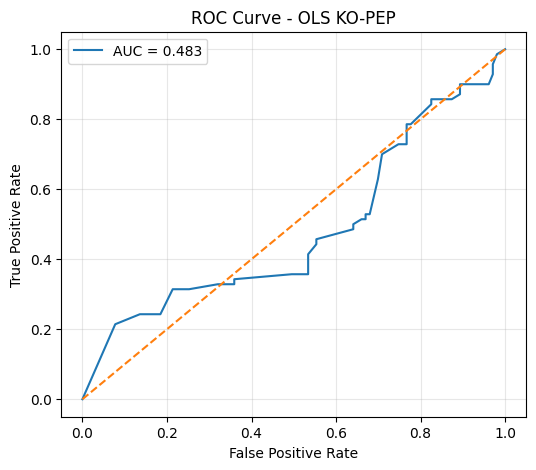

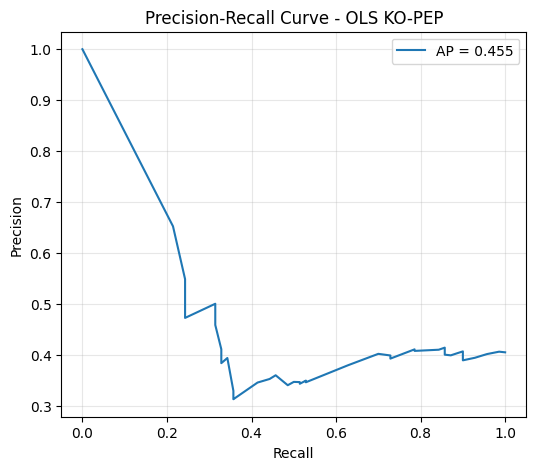

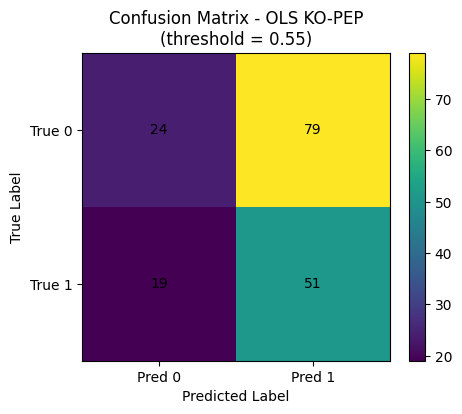

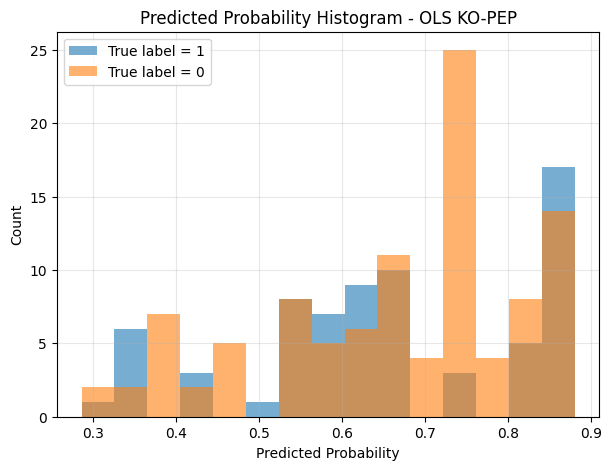

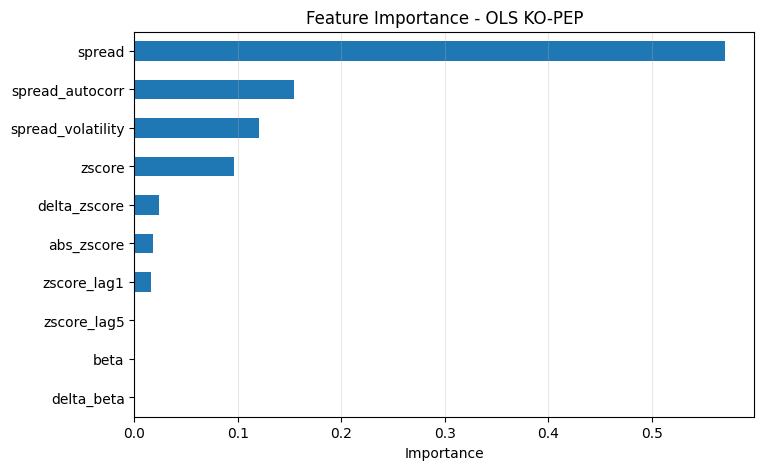

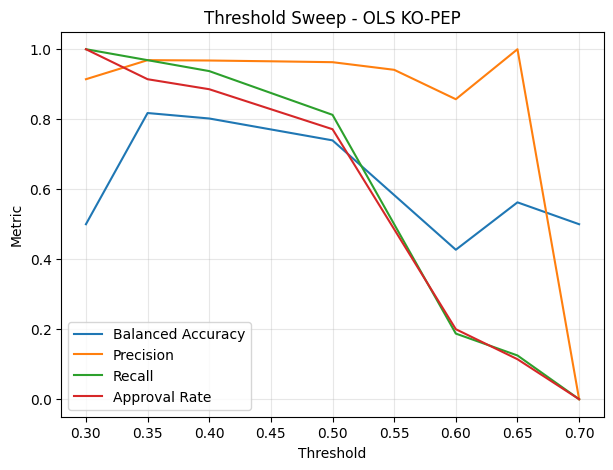


===== KF KO-PEP =====


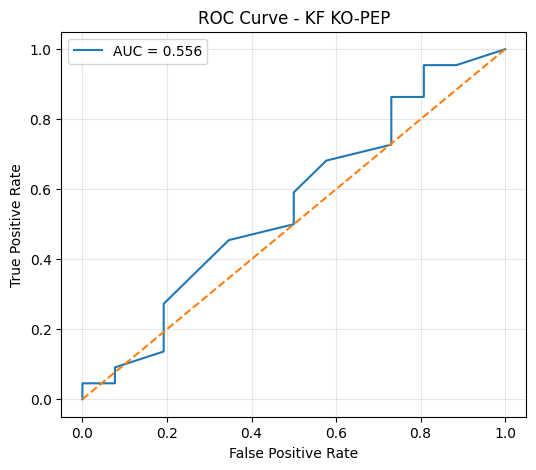

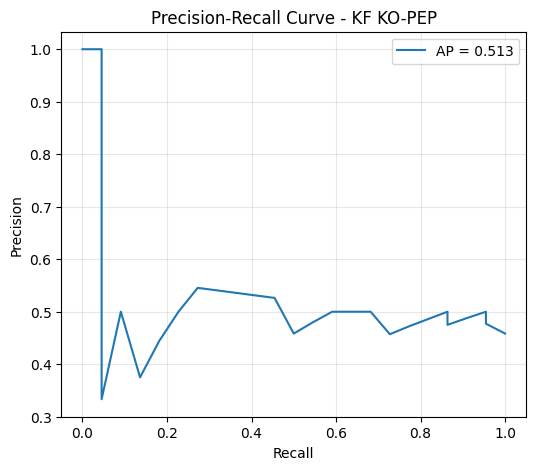

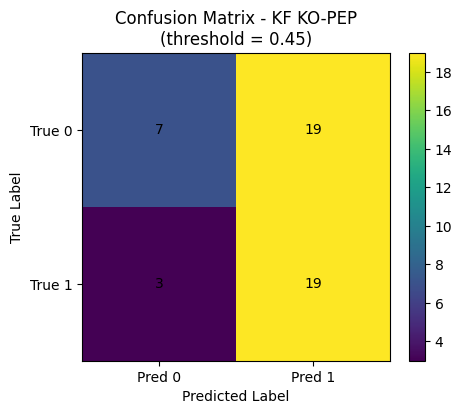

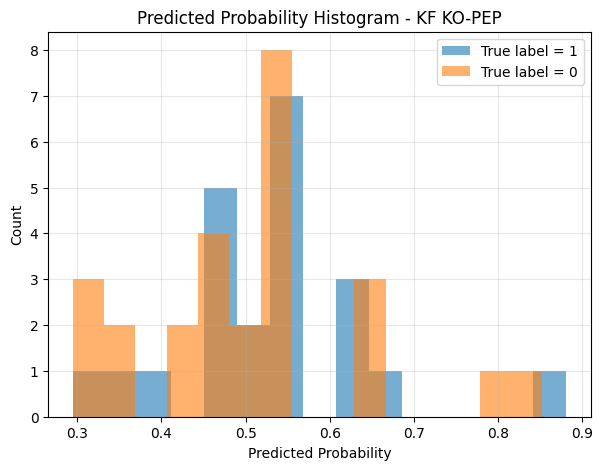

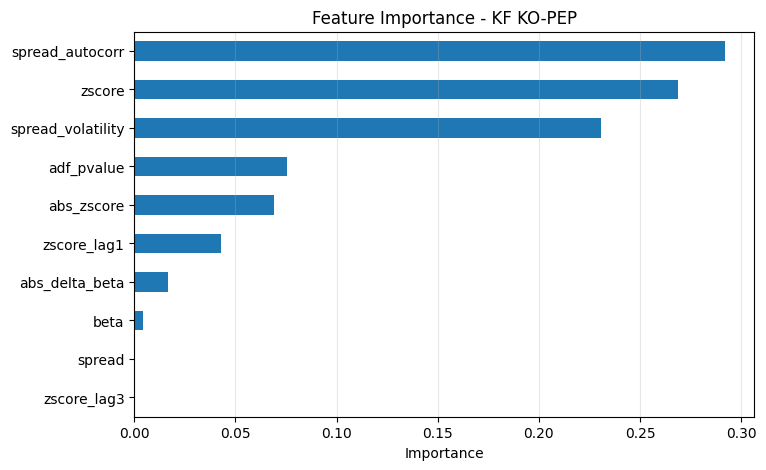

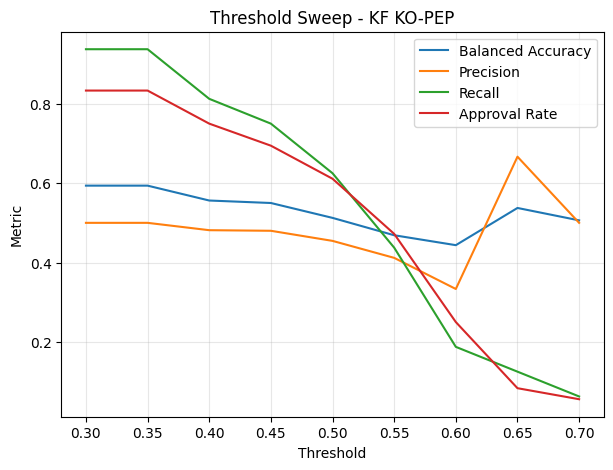


===== OLS XOM-CVX =====


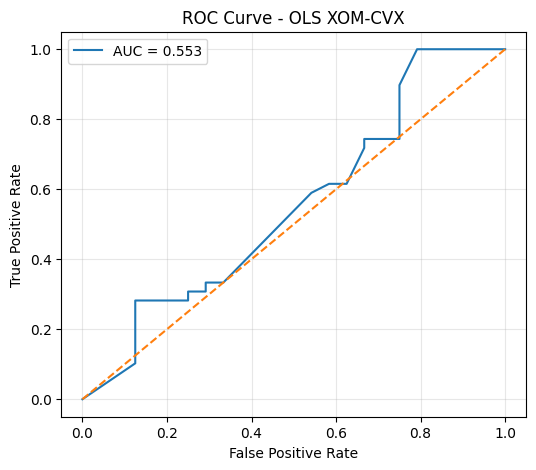

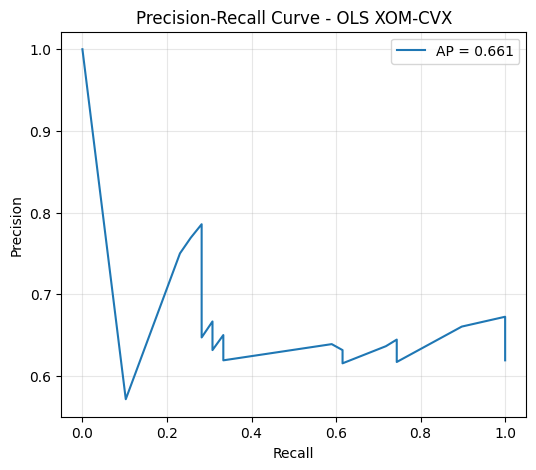

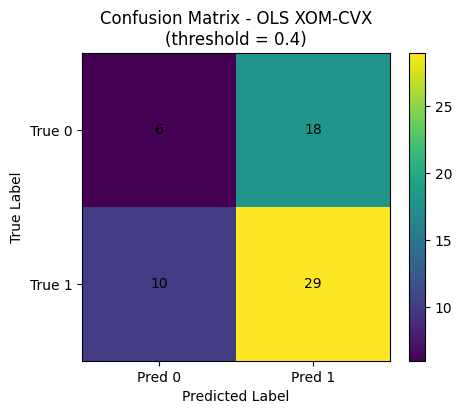

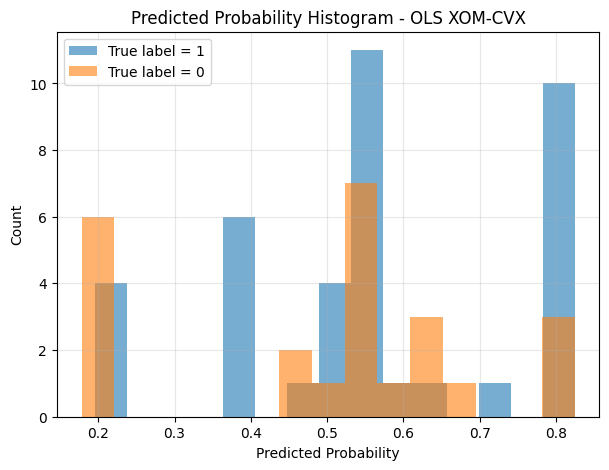

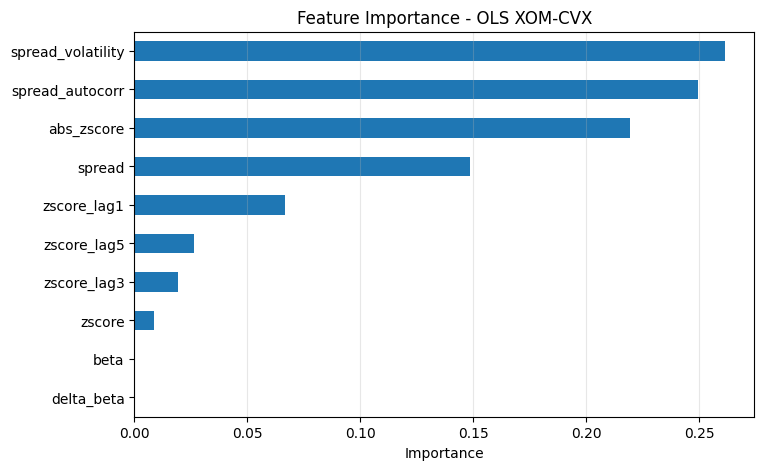

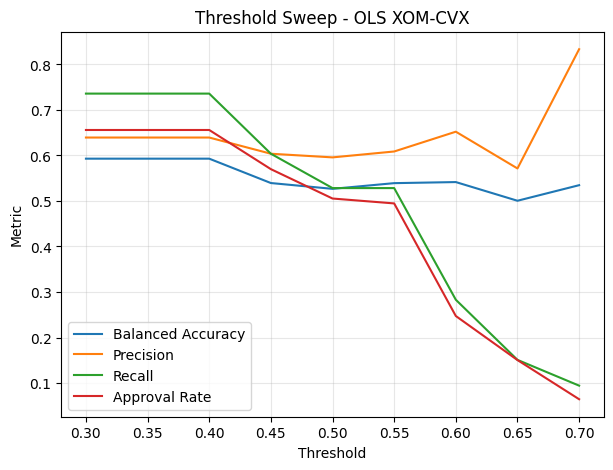


===== KF XOM-CVX =====


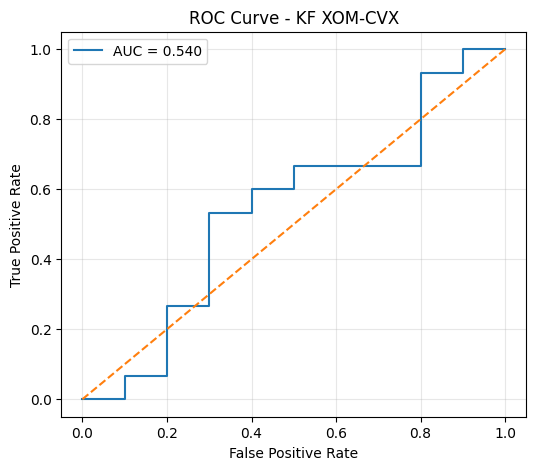

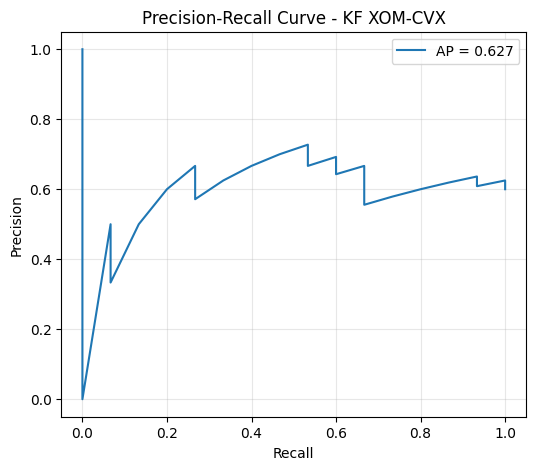

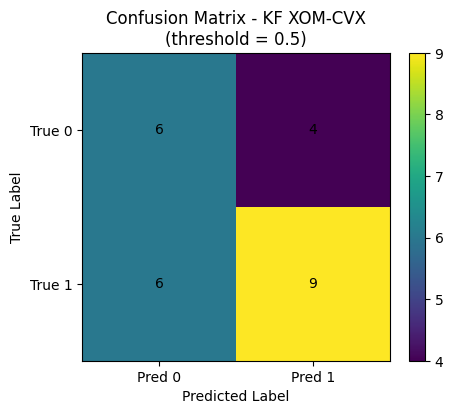

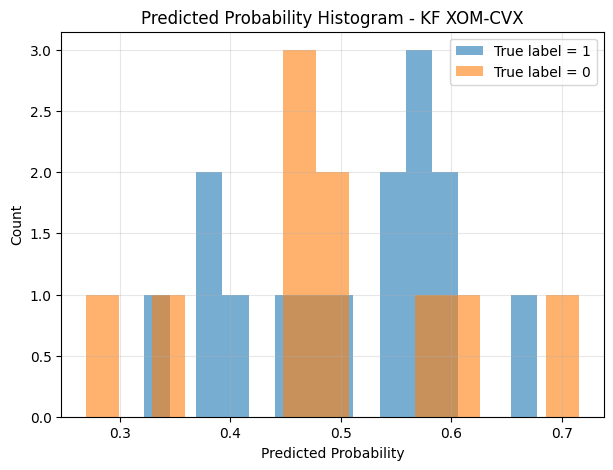

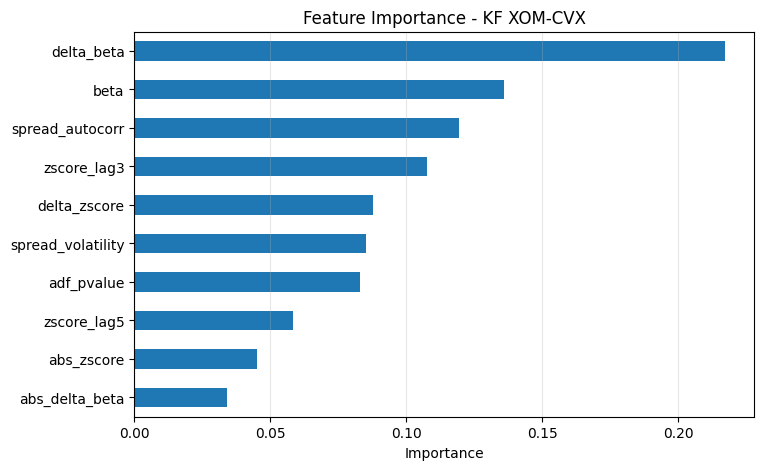

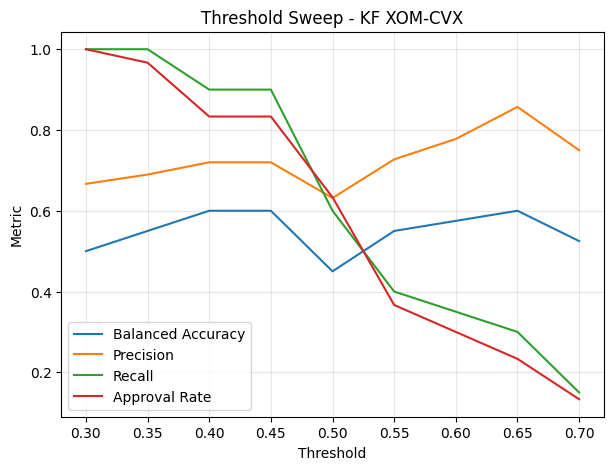

In [154]:
for name, info in model_plot_inputs.items():
    plot_model_diagnostics(
        name=name,
        y_true=info["y_true"],
        y_prob=info["y_prob"],
        result_dict=info["result"],
        threshold=info["threshold"],
        sweep_df=info["sweep"],
        top_n_features=10
    )

Include these in the report:

ROC curves for all 4 models

Threshold sweep for 1 representative OLS case and 1 representative Kalman case

Feature importance for the best model(s), especially KF XOM-CVX

Confusion matrix for KF XOM-CVX test

(Optional)
Probability histogram if you want to show why some models are weak

In [161]:
#check if overfit

def evaluate_split_for_overfit(result, train_df, val_df, test_df, threshold):
    model = result["model"]
    imputer = result["imputer"]
    feature_cols = result["feature_cols"]

    def _eval(name, df):
        X = df[feature_cols]
        y = df["label"].astype(int).values

        X_imp = imputer.transform(X)

        prob = model.predict_proba(X_imp)[:, 1]
        pred = (prob >= threshold).astype(int)

        out = {
            "split": name,
            "n": len(y),
            "pos_ratio": y.mean(),
            "approval_rate": pred.mean(),
            "accuracy": accuracy_score(y, pred),
            "balanced_accuracy": balanced_accuracy_score(y, pred),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "auc": roc_auc_score(y, prob) if len(np.unique(y)) > 1 else np.nan
        }

        return out

    rows = [
        _eval("train", train_df),
        _eval("validation", val_df),
        _eval("test", test_df)
    ]

    return pd.DataFrame(rows)

In [162]:
overfit_ols_ko = evaluate_split_for_overfit(
    result_ols_ko,
    train_ols_ko,
    val_ols_ko,
    test_ols_ko,
    threshold=0.55
)

overfit_kf_ko = evaluate_split_for_overfit(
    result_kf_ko,
    train_kf_ko,
    val_kf_ko,
    test_kf_ko,
    threshold=0.45
)

overfit_ols_xom = evaluate_split_for_overfit(
    result_ols_xom,
    train_ols_xom,
    val_ols_xom,
    test_ols_xom,
    threshold=0.40
)

overfit_kf_xom = evaluate_split_for_overfit(
    result_kf_xom,
    train_kf_xom,
    val_kf_xom,
    test_kf_xom,
    threshold=0.50
)

print("OLS KO-PEP")
print(overfit_ols_ko)

print("\nKF KO-PEP")
print(overfit_kf_ko)

print("\nOLS XOM-CVX")
print(overfit_ols_xom)

print("\nKF XOM-CVX")
print(overfit_kf_xom)

OLS KO-PEP
        split    n  pos_ratio  approval_rate  accuracy  balanced_accuracy  \
0       train  323   0.597523       0.430341  0.708978           0.731367   
1  validation   35   0.914286       0.485714  0.514286           0.583333   
2        test  173   0.404624       0.751445  0.433526           0.480791   

   precision    recall        f1       auc  
0   0.856115  0.616580  0.716867  0.814468  
1   0.941176  0.500000  0.653061  0.703125  
2   0.392308  0.728571  0.510000  0.483148  

KF KO-PEP
        split    n  pos_ratio  approval_rate  accuracy  balanced_accuracy  \
0       train  146   0.575342       0.767123  0.780822           0.746160   
1  validation   36   0.444444       0.694444  0.527778           0.550000   
2        test   48   0.458333       0.791667  0.541667           0.566434   

   precision    recall        f1       auc  
0   0.732143  0.976190  0.836735  0.888441  
1   0.480000  0.750000  0.585366  0.526563  
2   0.500000  0.863636  0.633333  0.555944  


Adaboost is overfitting

AdaBoost was tested as an interpretable benchmark model. However, it showed clear overfitting: training AUC was high, but validation and test AUC were close to random. Therefore, we do not use AdaBoost as the main ML filter. Instead, we treat it as a benchmark and move to a more regularized model / sequence-based model.

In [155]:
selected_thresholds = {
    "OLS KO-PEP": 0.55,
    "KF KO-PEP": 0.45,
    "OLS XOM-CVX": 0.40,
    "KF XOM-CVX": 0.50
}

In [156]:
def create_ml_signal_file(dataset, result, pair, spread_model, threshold, ml_model="AdaBoost"):
    feature_cols = result["feature_cols"]
    model = result["model"]
    imputer = result["imputer"]

    X = dataset[feature_cols]
    X_imp = imputer.transform(X)

    prob = model.predict_proba(X_imp)[:, 1]
    signal = (prob >= threshold).astype(int)

    output = pd.DataFrame(index=dataset.index)
    output["date"] = output.index
    output["pair"] = pair
    output["spread_model"] = spread_model
    output["ml_model"] = ml_model
    output["z_score"] = dataset["zscore"]
    output["label"] = dataset["label"]
    output["prediction_probability"] = prob
    output["threshold"] = threshold
    output["ML_signal"] = signal

    return output.reset_index(drop=True)

In [159]:
signals_ols_ko = create_ml_signal_file(
    dataset_ols_ko_pep,
    result_ols_ko,
    pair="KO-PEP",
    spread_model="OLS",
    threshold=0.55
)

signals_kf_ko = create_ml_signal_file(
    dataset_kf_ko_pep,
    result_kf_ko,
    pair="KO-PEP",
    spread_model="Kalman",
    threshold=0.45
)

signals_ols_xom = create_ml_signal_file(
    dataset_ols_xom_cvx,
    result_ols_xom,
    pair="XOM-CVX",
    spread_model="OLS",
    threshold=0.40
)

signals_kf_xom = create_ml_signal_file(
    dataset_kf_xom_cvx,
    result_kf_xom,
    pair="XOM-CVX",
    spread_model="Kalman",
    threshold=0.50
)

ml_signals_adaboost = pd.concat(
    [signals_ols_ko, signals_kf_ko, signals_ols_xom, signals_kf_xom],
    axis=0
).sort_values(["pair", "spread_model", "date"])

ml_signals_adaboost.to_csv("ml_signals_adaboost.csv", index=False)

ml_signals_adaboost.head()

,date,pair,spread_model,ml_model,z_score,label,prediction_probability,threshold,ML_signal
0,2011-02-10,KO-PEP,Kalman,AdaBoost,2.067357,0.0,0.341870,0.45,0
1,2011-02-18,KO-PEP,Kalman,AdaBoost,2.171639,0.0,0.522262,0.45,1
2,2011-03-16,KO-PEP,Kalman,AdaBoost,-2.490819,1.0,0.470901,0.45,1
3,2011-04-12,KO-PEP,Kalman,AdaBoost,-2.051879,0.0,0.494510,0.45,1
4,2011-04-26,KO-PEP,Kalman,AdaBoost,-2.290733,0.0,0.470901,0.45,1


In [158]:
for name, df in {
    "OLS KO-PEP": signals_ols_ko,
    "KF KO-PEP": signals_kf_ko,
    "OLS XOM-CVX": signals_ols_xom,
    "KF XOM-CVX": signals_kf_xom,
}.items():
    print(name)
    print("rows:", len(df))
    print("approval rate:", df["ML_signal"].mean())
    print("avg prediction probability:", df["prediction_probability"].mean())
    print()

OLS KO-PEP
rows: 531
approval rate: 0.5386064030131826
avg prediction probability: 0.5612208679636105

KF KO-PEP
rows: 230
approval rate: 0.7608695652173914
avg prediction probability: 0.5165271501291809

OLS XOM-CVX
rows: 493
approval rate: 0.7931034482758621
avg prediction probability: 0.48810682399085153

KF XOM-CVX
rows: 201
approval rate: 0.5572139303482587
avg prediction probability: 0.5240324999348064



# Logistic Regression

In [163]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np
import pandas as pd

In [164]:
def evaluate_classifier(name, y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n=== {name} | threshold={threshold} ===")
    print("samples:", len(y_true))
    print("positive ratio:", y_true.mean())
    print("approval rate:", y_pred.mean())
    print("accuracy:", accuracy_score(y_true, y_pred))
    print("balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("precision:", precision_score(y_true, y_pred, zero_division=0))
    print("recall:", recall_score(y_true, y_pred, zero_division=0))
    print("f1:", f1_score(y_true, y_pred, zero_division=0))

    if len(np.unique(y_true)) > 1:
        print("auc:", roc_auc_score(y_true, y_prob))
    else:
        print("auc: NA")

    print("confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

In [165]:
def threshold_sweep(y_true, y_prob, thresholds=np.arange(0.30, 0.81, 0.05)):
    rows = []
    y_true = np.asarray(y_true).astype(int)

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        rows.append({
            "threshold": th,
            "approval_rate": y_pred.mean(),
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })

    return pd.DataFrame(rows)


def choose_threshold_with_constraint(sweep_df, min_approval=0.30, max_approval=0.70):
    candidate = sweep_df[
        (sweep_df["approval_rate"] >= min_approval) &
        (sweep_df["approval_rate"] <= max_approval)
    ].copy()

    if len(candidate) == 0:
        return sweep_df.sort_values("balanced_accuracy", ascending=False).head(5)

    return candidate.sort_values(["balanced_accuracy", "f1"], ascending=False).head(5)

In [166]:
def train_regularized_model(
    train_df,
    val_df,
    test_df,
    model_type="logistic",
    C=0.5,
    threshold=0.5
):
    drop_cols = ["label", "pair", "spread_model"]
    feature_cols = [c for c in train_df.columns if c not in drop_cols]

    X_train = train_df[feature_cols]
    y_train = train_df["label"].astype(int)

    X_val = val_df[feature_cols]
    y_val = val_df["label"].astype(int)

    X_test = test_df[feature_cols]
    y_test = test_df["label"].astype(int)

    if model_type == "logistic":
        clf = LogisticRegression(
            penalty="l2",
            C=C,
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )

    elif model_type == "linear_svm":
        clf = SVC(
            kernel="linear",
            C=C,
            class_weight="balanced",
            probability=True,
            random_state=42
        )

    else:
        raise ValueError("model_type must be 'logistic' or 'linear_svm'")

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", clf)
    ])

    model.fit(X_train, y_train)

    train_prob = model.predict_proba(X_train)[:, 1]
    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    evaluate_classifier("Train", y_train, train_prob, threshold)
    evaluate_classifier("Validation", y_val, val_prob, threshold)
    evaluate_classifier("Test", y_test, test_prob, threshold)

    return {
        "model": model,
        "model_type": model_type,
        "C": C,
        "feature_cols": feature_cols,
        "train_prob": train_prob,
        "val_prob": val_prob,
        "test_prob": test_prob
    }

In [167]:
logit_ols_ko = train_regularized_model(
    train_ols_ko, val_ols_ko, test_ols_ko,
    model_type="logistic",
    C=0.5,
    threshold=0.5
)

logit_kf_ko = train_regularized_model(
    train_kf_ko, val_kf_ko, test_kf_ko,
    model_type="logistic",
    C=0.5,
    threshold=0.5
)

logit_ols_xom = train_regularized_model(
    train_ols_xom, val_ols_xom, test_ols_xom,
    model_type="logistic",
    C=0.5,
    threshold=0.5
)

logit_kf_xom = train_regularized_model(
    train_kf_xom, val_kf_xom, test_kf_xom,
    model_type="logistic",
    C=0.5,
    threshold=0.5
)

c:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5291\Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5291\Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop


=== Train | threshold=0.5 ===
samples: 323
positive ratio: 0.5975232198142415
approval rate: 0.4953560371517028
accuracy: 0.6253869969040248
balanced accuracy: 0.6312873654842567
precision: 0.725
recall: 0.6010362694300518
f1: 0.6572237960339944
auc: 0.6910721402949382
confusion matrix:
[[ 86  44]
 [ 77 116]]

=== Validation | threshold=0.5 ===
samples: 35
positive ratio: 0.9142857142857143
approval rate: 0.45714285714285713
accuracy: 0.4857142857142857
balanced accuracy: 0.5677083333333333
precision: 0.9375
recall: 0.46875
f1: 0.625
auc: 0.6770833333333334
confusion matrix:
[[ 2  1]
 [17 15]]

=== Test | threshold=0.5 ===
samples: 173
positive ratio: 0.4046242774566474
approval rate: 0.7341040462427746
accuracy: 0.4508670520231214
balanced accuracy: 0.4953536754507628
precision: 0.4015748031496063
recall: 0.7285714285714285
f1: 0.5177664974619289
auc: 0.5515950069348127
confusion matrix:
[[27 76]
 [19 51]]

=== Train | threshold=0.5 ===
samples: 146
positive ratio: 0.5753424657534246

In [169]:
logit_sweeps = {}

for name, val_df, result in [
    ("OLS KO-PEP", val_ols_ko, logit_ols_ko),
    ("KF KO-PEP", val_kf_ko, logit_kf_ko),
    ("OLS XOM-CVX", val_ols_xom, logit_ols_xom),
    ("KF XOM-CVX", val_kf_xom, logit_kf_xom)
]:
    sweep = threshold_sweep(val_df["label"], result["val_prob"])
    logit_sweeps[name] = sweep

    print("\n", name, "Logistic Regression")
    print(choose_threshold_with_constraint(sweep, min_approval=0.30, max_approval=0.70))


 OLS KO-PEP Logistic Regression
   threshold  approval_rate  accuracy  balanced_accuracy  precision   recall  \
3       0.45       0.657143  0.685714           0.677083   0.956522  0.68750   
4       0.50       0.457143  0.485714           0.567708   0.937500  0.46875   

      f1  
3  0.800  
4  0.625  

 KF KO-PEP Logistic Regression
   threshold  approval_rate  accuracy  balanced_accuracy  precision  recall  \
4       0.50       0.472222  0.472222            0.46875   0.411765  0.4375   
2       0.40       0.694444  0.416667            0.43750   0.400000  0.6250   
3       0.45       0.583333  0.416667            0.42500   0.380952  0.5000   

         f1  
4  0.424242  
2  0.487805  
3  0.432432  

 OLS XOM-CVX Logistic Regression
   threshold  approval_rate  accuracy  balanced_accuracy  precision    recall  \
7       0.65       0.462366  0.634409           0.642453   0.720930  0.584906   
4       0.50       0.688172  0.645161           0.621226   0.656250  0.792453   
5       0.5

In [174]:
selected_logit_thresholds = {
    "OLS KO-PEP": 0.45,
    "KF KO-PEP": 0.50,
    "OLS XOM-CVX": 0.65,
    "KF XOM-CVX": 0.60
}

In [175]:
evaluate_classifier(
    "Logistic OLS KO-PEP Test",
    test_ols_ko["label"],
    logit_ols_ko["test_prob"],
    threshold=0.45
)

evaluate_classifier(
    "Logistic KF KO-PEP Test",
    test_kf_ko["label"],
    logit_kf_ko["test_prob"],
    threshold=0.50
)

evaluate_classifier(
    "Logistic OLS XOM-CVX Test",
    test_ols_xom["label"],
    logit_ols_xom["test_prob"],
    threshold=0.65
)

evaluate_classifier(
    "Logistic KF XOM-CVX Test",
    test_kf_xom["label"],
    logit_kf_xom["test_prob"],
    threshold=0.60
)


=== Logistic OLS KO-PEP Test | threshold=0.45 ===
samples: 173
positive ratio: 0.4046242774566474
approval rate: 0.8497109826589595
accuracy: 0.4161849710982659
balanced accuracy: 0.482246879334258
precision: 0.3945578231292517
recall: 0.8285714285714286
f1: 0.5345622119815668
auc: 0.5515950069348127
confusion matrix:
[[14 89]
 [12 58]]

=== Logistic KF KO-PEP Test | threshold=0.5 ===
samples: 48
positive ratio: 0.4583333333333333
approval rate: 0.25
accuracy: 0.5
balanced accuracy: 0.479020979020979
precision: 0.4166666666666667
recall: 0.22727272727272727
f1: 0.29411764705882354
auc: 0.3531468531468531
confusion matrix:
[[19  7]
 [17  5]]

=== Logistic OLS XOM-CVX Test | threshold=0.65 ===
samples: 63
positive ratio: 0.6190476190476191
approval rate: 0.20634920634920634
accuracy: 0.49206349206349204
balanced accuracy: 0.5657051282051282
precision: 0.7692307692307693
recall: 0.2564102564102564
f1: 0.38461538461538464
auc: 0.4978632478632478
confusion matrix:
[[21  3]
 [29 10]]

=== L

In [171]:
def overfit_table(result, train_df, val_df, test_df, threshold=0.5):
    rows = []

    for split_name, df, prob_key in [
        ("train", train_df, "train_prob"),
        ("validation", val_df, "val_prob"),
        ("test", test_df, "test_prob")
    ]:
        y = df["label"].astype(int).values
        prob = result[prob_key]
        pred = (prob >= threshold).astype(int)

        rows.append({
            "split": split_name,
            "n": len(y),
            "pos_ratio": y.mean(),
            "approval_rate": pred.mean(),
            "accuracy": accuracy_score(y, pred),
            "balanced_accuracy": balanced_accuracy_score(y, pred),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "auc": roc_auc_score(y, prob) if len(np.unique(y)) > 1 else np.nan
        })

    return pd.DataFrame(rows)

In [176]:
print("Logistic OLS KO-PEP")
print(overfit_table(logit_ols_ko, train_ols_ko, val_ols_ko, test_ols_ko, threshold=0.45))

print("Logistic OLS XOM-CVX")
print(overfit_table(logit_ols_xom, train_ols_xom, val_ols_xom, test_ols_xom, threshold=0.5))

print("Logistic KF KO-PEP")
print(overfit_table(logit_kf_ko, train_kf_ko, val_kf_ko, test_kf_ko, threshold=0.65))

print("Logistic KF XOM-CVX")
print(overfit_table(logit_kf_xom, train_kf_xom, val_kf_xom, test_kf_xom, threshold=0.6))






Logistic OLS KO-PEP
        split    n  pos_ratio  approval_rate  accuracy  balanced_accuracy  \
0       train  323   0.597523       0.585139  0.647059           0.635612   
1  validation   35   0.914286       0.657143  0.685714           0.677083   
2        test  173   0.404624       0.849711  0.416185           0.482247   

   precision    recall        f1       auc  
0   0.708995  0.694301  0.701571  0.691072  
1   0.956522  0.687500  0.800000  0.677083  
2   0.394558  0.828571  0.534562  0.551595  
Logistic OLS XOM-CVX
        split    n  pos_ratio  approval_rate  accuracy  balanced_accuracy  \
0       train  337   0.543027       0.534125  0.640950           0.639043   
1  validation   93   0.569892       0.688172  0.645161           0.621226   
2        test   63   0.619048       0.460317  0.492063           0.501603   

   precision    recall        f1       auc  
0   0.672222  0.661202  0.666667  0.702683  
1   0.656250  0.792453  0.717949  0.654717  
2   0.620690  0.461538  0.

# Linear SVM

In [168]:
svm_ols_ko = train_regularized_model(
    train_ols_ko, val_ols_ko, test_ols_ko,
    model_type="linear_svm",
    C=0.5,
    threshold=0.5
)

svm_kf_ko = train_regularized_model(
    train_kf_ko, val_kf_ko, test_kf_ko,
    model_type="linear_svm",
    C=0.5,
    threshold=0.5
)

svm_ols_xom = train_regularized_model(
    train_ols_xom, val_ols_xom, test_ols_xom,
    model_type="linear_svm",
    C=0.5,
    threshold=0.5
)

svm_kf_xom = train_regularized_model(
    train_kf_xom, val_kf_xom, test_kf_xom,
    model_type="linear_svm",
    C=0.5,
    threshold=0.5
)


=== Train | threshold=0.5 ===
samples: 323
positive ratio: 0.5975232198142415
approval rate: 0.7244582043343654
accuracy: 0.6749226006191951
balanced accuracy: 0.6363292148266242
precision: 0.688034188034188
recall: 0.8341968911917098
f1: 0.7540983606557377
auc: 0.6964527700278995
confusion matrix:
[[ 57  73]
 [ 32 161]]

=== Validation | threshold=0.5 ===
samples: 35
positive ratio: 0.9142857142857143
approval rate: 0.9428571428571428
accuracy: 0.9142857142857143
balanced accuracy: 0.6510416666666666
precision: 0.9393939393939394
recall: 0.96875
f1: 0.9538461538461539
auc: 0.6770833333333334
confusion matrix:
[[ 1  2]
 [ 1 31]]

=== Test | threshold=0.5 ===
samples: 173
positive ratio: 0.4046242774566474
approval rate: 0.9364161849710982
accuracy: 0.41040462427745666
balanced accuracy: 0.4934119278779473
precision: 0.4012345679012346
recall: 0.9285714285714286
f1: 0.5603448275862069
auc: 0.5375866851595006
confusion matrix:
[[ 6 97]
 [ 5 65]]

=== Train | threshold=0.5 ===
samples: 1

In [170]:
svm_sweeps = {}

for name, val_df, result in [
    ("OLS KO-PEP", val_ols_ko, svm_ols_ko),
    ("KF KO-PEP", val_kf_ko, svm_kf_ko),
    ("OLS XOM-CVX", val_ols_xom, svm_ols_xom),
    ("KF XOM-CVX", val_kf_xom, svm_kf_xom)
]:
    sweep = threshold_sweep(val_df["label"], result["val_prob"])
    svm_sweeps[name] = sweep

    print("\n", name, "Linear SVM")
    print(choose_threshold_with_constraint(sweep, min_approval=0.30, max_approval=0.70))


 OLS KO-PEP Linear SVM
   threshold  approval_rate  accuracy  balanced_accuracy  precision   recall  \
5       0.55       0.685714  0.714286           0.692708   0.958333  0.71875   

         f1  
5  0.821429  

 KF KO-PEP Linear SVM
   threshold  approval_rate  accuracy  balanced_accuracy  precision  recall  \
6       0.60       0.333333  0.444444              0.425   0.333333    0.25   
5       0.55       0.611111  0.388889              0.400   0.363636    0.50   

         f1  
6  0.285714  
5  0.421053  

 OLS XOM-CVX Linear SVM
   threshold  approval_rate  accuracy  balanced_accuracy  precision    recall  \
7       0.65       0.505376  0.634409           0.636321   0.702128  0.622642   
8       0.70       0.311828  0.591398           0.620047   0.758621  0.415094   
6       0.60       0.623656  0.602151           0.586557   0.637931  0.698113   

         f1  
7  0.660000  
8  0.536585  
6  0.666667  

 KF XOM-CVX Linear SVM
   threshold  approval_rate  accuracy  balanced_accura

In [ ]:
print("\nSVM OLS KO-PEP")
print(overfit_table(svm_ols_ko, train_ols_ko, val_ols_ko, test_ols_ko, threshold=0.5))

# Candidate models:
1. Binary Tree / Shallow Decision Tree
2. KNN
3. Random Forest

Model selection:
Use validation set only to choose the best model + hyperparameters + threshold.
Final test set only used once for out-of-sample evaluation.

In [178]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np
import pandas as pd

In [179]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": threshold,
        "approval_rate": y_pred.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    }

    return out


def threshold_sweep(y_true, y_prob, thresholds=np.arange(0.30, 0.81, 0.05)):
    rows = []

    for th in thresholds:
        row = compute_metrics(y_true, y_prob, threshold=th)
        rows.append(row)

    return pd.DataFrame(rows)


def choose_best_threshold(
    y_true,
    y_prob,
    min_approval=0.20,
    max_approval=0.80,
    metric="balanced_accuracy"
):
    sweep = threshold_sweep(y_true, y_prob)

    candidates = sweep[
        (sweep["approval_rate"] >= min_approval) &
        (sweep["approval_rate"] <= max_approval)
    ].copy()

    if len(candidates) == 0:
        candidates = sweep.copy()

    best = candidates.sort_values(
        [metric, "f1"],
        ascending=[False, False]
    ).iloc[0]

    return best, sweep

In [180]:
def build_model(model_type, params):
    if model_type == "tree":
        clf = DecisionTreeClassifier(
            max_depth=params.get("max_depth", 2),
            min_samples_leaf=params.get("min_samples_leaf", 20),
            class_weight="balanced",
            random_state=42
        )

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", clf)
        ])

    elif model_type == "knn":
        clf = KNeighborsClassifier(
            n_neighbors=params.get("n_neighbors", 15),
            weights=params.get("weights", "distance"),
            metric=params.get("metric", "minkowski")
        )

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

    elif model_type == "random_forest":
        clf = RandomForestClassifier(
            n_estimators=params.get("n_estimators", 100),
            max_depth=params.get("max_depth", 3),
            min_samples_leaf=params.get("min_samples_leaf", 20),
            max_features=params.get("max_features", "sqrt"),
            class_weight="balanced",
            random_state=42
        )

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", clf)
        ])

    else:
        raise ValueError("model_type must be 'tree', 'knn', or 'random_forest'")

    return model

In [181]:
model_grid = []

# Binary tree / shallow decision tree
for depth in [1, 2, 3]:
    for leaf in [10, 20, 30, 40]:
        model_grid.append({
            "model_type": "tree",
            "params": {
                "max_depth": depth,
                "min_samples_leaf": leaf
            }
        })

# KNN
for k in [5, 10, 15, 20, 30]:
    for weights in ["uniform", "distance"]:
        model_grid.append({
            "model_type": "knn",
            "params": {
                "n_neighbors": k,
                "weights": weights
            }
        })

# Random Forest
for depth in [2, 3, 4]:
    for leaf in [10, 20, 30]:
        for n_est in [100, 200]:
            model_grid.append({
                "model_type": "random_forest",
                "params": {
                    "n_estimators": n_est,
                    "max_depth": depth,
                    "min_samples_leaf": leaf,
                    "max_features": "sqrt"
                }
            })

In [182]:
def model_selection_for_dataset(
    train_df,
    val_df,
    test_df,
    dataset_name,
    model_grid,
    min_approval=0.20,
    max_approval=0.80
):
    drop_cols = ["label", "pair", "spread_model"]
    feature_cols = [c for c in train_df.columns if c not in drop_cols]

    X_train = train_df[feature_cols]
    y_train = train_df["label"].astype(int).values

    X_val = val_df[feature_cols]
    y_val = val_df["label"].astype(int).values

    X_test = test_df[feature_cols]
    y_test = test_df["label"].astype(int).values

    rows = []
    fitted_models = {}

    for i, spec in enumerate(model_grid):
        model_type = spec["model_type"]
        params = spec["params"]

        model = build_model(model_type, params)
        model.fit(X_train, y_train)

        train_prob = model.predict_proba(X_train)[:, 1]
        val_prob = model.predict_proba(X_val)[:, 1]

        train_auc = roc_auc_score(y_train, train_prob) if len(np.unique(y_train)) > 1 else np.nan
        val_auc = roc_auc_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan

        best_th_row, val_sweep = choose_best_threshold(
            y_val,
            val_prob,
            min_approval=min_approval,
            max_approval=max_approval,
            metric="balanced_accuracy"
        )

        auc_gap = train_auc - val_auc

        row = {
            "model_id": i,
            "dataset": dataset_name,
            "model_type": model_type,
            "params": params,
            "train_auc": train_auc,
            "val_auc": val_auc,
            "auc_gap": auc_gap,
            "selected_threshold": best_th_row["threshold"],
            "val_approval_rate": best_th_row["approval_rate"],
            "val_balanced_accuracy": best_th_row["balanced_accuracy"],
            "val_precision": best_th_row["precision"],
            "val_recall": best_th_row["recall"],
            "val_f1": best_th_row["f1"]
        }

        rows.append(row)

        fitted_models[i] = {
            "model": model,
            "feature_cols": feature_cols,
            "train_prob": train_prob,
            "val_prob": val_prob,
            "val_sweep": val_sweep
        }

    results = pd.DataFrame(rows)

    # Selection rule:
    # prioritize validation AUC and balanced accuracy,
    # penalize large train-validation AUC gap
    results["selection_score"] = (
        results["val_auc"].fillna(0)
        + 0.50 * results["val_balanced_accuracy"].fillna(0)
        - 0.25 * results["auc_gap"].clip(lower=0).fillna(0)
    )

    results_sorted = results.sort_values(
        ["selection_score", "val_auc", "val_balanced_accuracy"],
        ascending=[False, False, False]
    )

    best_row = results_sorted.iloc[0]
    best_id = int(best_row["model_id"])
    best_model_info = fitted_models[best_id]

    best_model = best_model_info["model"]
    threshold = float(best_row["selected_threshold"])

    test_prob = best_model.predict_proba(X_test)[:, 1]
    test_metrics = compute_metrics(y_test, test_prob, threshold=threshold)

    print(f"\n==============================")
    print(f"Best model for {dataset_name}")
    print(f"Model type: {best_row['model_type']}")
    print(f"Params: {best_row['params']}")
    print(f"Selected threshold: {threshold}")
    print(f"Train AUC: {best_row['train_auc']:.3f}")
    print(f"Val AUC: {best_row['val_auc']:.3f}")
    print(f"AUC gap: {best_row['auc_gap']:.3f}")
    print("\nValidation metrics:")
    print(best_row[[
        "val_approval_rate",
        "val_balanced_accuracy",
        "val_precision",
        "val_recall",
        "val_f1"
    ]])
    print("\nTest metrics:")
    print(pd.Series(test_metrics))

    y_test_pred = (test_prob >= threshold).astype(int)
    print("\nTest confusion matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    return {
        "dataset_name": dataset_name,
        "results": results_sorted,
        "best_row": best_row,
        "best_model": best_model,
        "feature_cols": feature_cols,
        "threshold": threshold,
        "test_prob": test_prob,
        "test_metrics": test_metrics
    }

In [183]:
selection_ols_ko = model_selection_for_dataset(
    train_ols_ko,
    val_ols_ko,
    test_ols_ko,
    dataset_name="OLS KO-PEP",
    model_grid=model_grid,
    min_approval=0.20,
    max_approval=0.80
)

selection_kf_ko = model_selection_for_dataset(
    train_kf_ko,
    val_kf_ko,
    test_kf_ko,
    dataset_name="KF KO-PEP",
    model_grid=model_grid,
    min_approval=0.20,
    max_approval=0.80
)

selection_ols_xom = model_selection_for_dataset(
    train_ols_xom,
    val_ols_xom,
    test_ols_xom,
    dataset_name="OLS XOM-CVX",
    model_grid=model_grid,
    min_approval=0.20,
    max_approval=0.80
)

selection_kf_xom = model_selection_for_dataset(
    train_kf_xom,
    val_kf_xom,
    test_kf_xom,
    dataset_name="KF XOM-CVX",
    model_grid=model_grid,
    min_approval=0.20,
    max_approval=0.80
)


Best model for OLS KO-PEP
Model type: tree
Params: {'max_depth': 3, 'min_samples_leaf': 20}
Selected threshold: 0.49999999999999994
Train AUC: 0.747
Val AUC: 0.906
AUC gap: -0.159

Validation metrics:
val_approval_rate        0.657143
val_balanced_accuracy    0.859375
val_precision                 1.0
val_recall                0.71875
val_f1                   0.836364
Name: 9, dtype: object

Test metrics:
threshold            0.500000
approval_rate        0.491329
accuracy             0.601156
balanced_accuracy    0.603259
precision            0.505882
recall               0.614286
f1                   0.554839
auc                  0.577184
dtype: float64

Test confusion matrix:
[[61 42]
 [27 43]]

Best model for KF KO-PEP
Model type: knn
Params: {'n_neighbors': 20, 'weights': 'uniform'}
Selected threshold: 0.5499999999999999
Train AUC: 0.649
Val AUC: 0.527
AUC gap: 0.122

Validation metrics:
val_approval_rate             0.5
val_balanced_accuracy     0.55625
val_precision            

### Model Selection Results

We compare three lower-capacity ML models: a shallow decision tree, KNN, and a constrained random forest. The models are selected using the validation set only. The test set is reserved for final out-of-sample evaluation.

The selected models show mixed predictive performance. For KO-PEP, the OLS-based model achieves moderate out-of-sample performance, while the Kalman-based model is weak. For XOM-CVX, the results are stronger, especially under the Kalman spread construction. The best result is obtained for KF XOM-CVX, where a shallow decision tree achieves a test AUC of 0.667, balanced accuracy of 0.667, and precision of 0.800.

This suggests that the ML filter is more useful for the more regime-sensitive XOM-CVX pair than for KO-PEP. This is consistent with the economic intuition that XOM-CVX is more exposed to energy-market regime shifts, making trade timing more important.

Best ML result: KF XOM-CVX

Weakest ML result: KF KO-PEP

ML filtering does not uniformly improve every pair, but it appears more useful for regime-sensitive pairs, especially when combined with Kalman spread construction.

In [184]:
def create_selected_model_signal_file(dataset, selection_result, pair, spread_model):
    model = selection_result["best_model"]
    feature_cols = selection_result["feature_cols"]
    threshold = selection_result["threshold"]
    model_type = selection_result["best_row"]["model_type"]

    X = dataset[feature_cols]
    prob = model.predict_proba(X)[:, 1]
    signal = (prob >= threshold).astype(int)

    output = pd.DataFrame(index=dataset.index)
    output["date"] = output.index
    output["pair"] = pair
    output["spread_model"] = spread_model
    output["ml_model"] = model_type
    output["z_score"] = dataset["zscore"]
    output["label"] = dataset["label"]
    output["prediction_probability"] = prob
    output["threshold"] = threshold
    output["ML_signal"] = signal

    return output.reset_index(drop=True)

In [185]:
OUTPUT_DIR = DATA_DIR + "/output"
signals_ols_ko = create_selected_model_signal_file(
    dataset_ols_ko_pep,
    selection_ols_ko,
    pair="KO-PEP",
    spread_model="OLS"
)

signals_kf_ko = create_selected_model_signal_file(
    dataset_kf_ko_pep,
    selection_kf_ko,
    pair="KO-PEP",
    spread_model="Kalman"
)

signals_ols_xom = create_selected_model_signal_file(
    dataset_ols_xom_cvx,
    selection_ols_xom,
    pair="XOM-CVX",
    spread_model="OLS"
)

signals_kf_xom = create_selected_model_signal_file(
    dataset_kf_xom_cvx,
    selection_kf_xom,
    pair="XOM-CVX",
    spread_model="Kalman"
)

ml_signals = pd.concat(
    [signals_ols_ko, signals_kf_ko, signals_ols_xom, signals_kf_xom],
    axis=0
).sort_values(["pair", "spread_model", "date"])


ml_signals.to_csv(OUTPUT_DIR + "/ml_signals_shallow.csv", index=False)

ml_signals.head()

,date,pair,spread_model,ml_model,z_score,label,prediction_probability,threshold,ML_signal
0,2011-02-10,KO-PEP,Kalman,knn,2.067357,0.0,0.50,0.55,0
1,2011-02-18,KO-PEP,Kalman,knn,2.171639,0.0,0.50,0.55,0
2,2011-03-16,KO-PEP,Kalman,knn,-2.490819,1.0,0.40,0.55,0
3,2011-04-12,KO-PEP,Kalman,knn,-2.051879,0.0,0.30,0.55,0
4,2011-04-26,KO-PEP,Kalman,knn,-2.290733,0.0,0.35,0.55,0


In [186]:
selected_model_summary = pd.DataFrame([
    {
        "dataset": "OLS KO-PEP",
        "selected_model": selection_ols_ko["best_row"]["model_type"],
        "params": selection_ols_ko["best_row"]["params"],
        "threshold": selection_ols_ko["threshold"],
        "test_auc": selection_ols_ko["test_metrics"]["auc"],
        "test_balanced_accuracy": selection_ols_ko["test_metrics"]["balanced_accuracy"],
        "test_precision": selection_ols_ko["test_metrics"]["precision"],
        "test_recall": selection_ols_ko["test_metrics"]["recall"],
        "test_f1": selection_ols_ko["test_metrics"]["f1"],
        "test_approval_rate": selection_ols_ko["test_metrics"]["approval_rate"],
    },
    {
        "dataset": "KF KO-PEP",
        "selected_model": selection_kf_ko["best_row"]["model_type"],
        "params": selection_kf_ko["best_row"]["params"],
        "threshold": selection_kf_ko["threshold"],
        "test_auc": selection_kf_ko["test_metrics"]["auc"],
        "test_balanced_accuracy": selection_kf_ko["test_metrics"]["balanced_accuracy"],
        "test_precision": selection_kf_ko["test_metrics"]["precision"],
        "test_recall": selection_kf_ko["test_metrics"]["recall"],
        "test_f1": selection_kf_ko["test_metrics"]["f1"],
        "test_approval_rate": selection_kf_ko["test_metrics"]["approval_rate"],
    },
    {
        "dataset": "OLS XOM-CVX",
        "selected_model": selection_ols_xom["best_row"]["model_type"],
        "params": selection_ols_xom["best_row"]["params"],
        "threshold": selection_ols_xom["threshold"],
        "test_auc": selection_ols_xom["test_metrics"]["auc"],
        "test_balanced_accuracy": selection_ols_xom["test_metrics"]["balanced_accuracy"],
        "test_precision": selection_ols_xom["test_metrics"]["precision"],
        "test_recall": selection_ols_xom["test_metrics"]["recall"],
        "test_f1": selection_ols_xom["test_metrics"]["f1"],
        "test_approval_rate": selection_ols_xom["test_metrics"]["approval_rate"],
    },
    {
        "dataset": "KF XOM-CVX",
        "selected_model": selection_kf_xom["best_row"]["model_type"],
        "params": selection_kf_xom["best_row"]["params"],
        "threshold": selection_kf_xom["threshold"],
        "test_auc": selection_kf_xom["test_metrics"]["auc"],
        "test_balanced_accuracy": selection_kf_xom["test_metrics"]["balanced_accuracy"],
        "test_precision": selection_kf_xom["test_metrics"]["precision"],
        "test_recall": selection_kf_xom["test_metrics"]["recall"],
        "test_f1": selection_kf_xom["test_metrics"]["f1"],
        "test_approval_rate": selection_kf_xom["test_metrics"]["approval_rate"],
    },
])

selected_model_summary

,dataset,selected_model,params,threshold,test_auc,test_balanced_accuracy,test_precision,test_recall,test_f1,test_approval_rate
0,OLS KO-PEP,tree,"{'max_depth': 3, 'min_samples_leaf': 20}",0.50,0.577184,0.603259,0.505882,0.614286,0.554839,0.491329
1,KF KO-PEP,knn,"{'n_neighbors': 20, 'weights': 'uniform'}",0.55,0.514860,0.466783,0.411765,0.318182,0.358974,0.354167
2,OLS XOM-CVX,knn,"{'n_neighbors': 5, 'weights': 'uniform'}",0.30,0.634081,0.493590,0.615385,0.820513,0.703297,0.825397
3,KF XOM-CVX,tree,"{'max_depth': 1, 'min_samples_leaf': 10}",0.45,0.666667,0.666667,0.800000,0.533333,0.640000,0.400000


# expanded parameter tuning on our candidate models

1. Use the safer grid.
2. Add feature-set tuning.
3. Penalize train-validation AUC gap.
4. Select on validation only.
5. Evaluate test only after selection.

In [200]:
# ---------------------------------------------------
# Feature sets for model selection
# ---------------------------------------------------

full_features = [
    "spread",
    "zscore",
    "abs_zscore",
    "zscore_lag1",
    "zscore_lag3",
    "zscore_lag5",
    "delta_zscore",
    "spread_volatility",
    "spread_autocorr",
    "adf_pvalue",
    "beta",
    "delta_beta",
    "abs_delta_beta"
]

reduced_features = [
    "abs_zscore",
    "zscore_lag1",
    "zscore_lag3",
    "delta_zscore",
    "spread_volatility",
    "spread_autocorr",
    "adf_pvalue",
    "delta_beta",
    "abs_delta_beta"
]

minimal_features = [
    "abs_zscore",
    "delta_zscore",
    "spread_volatility",
    "adf_pvalue",
    "abs_delta_beta"
]

feature_sets = {
    "full": full_features,
    "reduced": reduced_features,
    "minimal": minimal_features,
}

In [201]:
def clean_selected_features(train_df, feature_list, missing_threshold=0.5):
    selected = []

    for col in feature_list:
        if col not in train_df.columns:
            continue

        # Drop features with too many missing values
        if train_df[col].isna().mean() > missing_threshold:
            continue

        # Drop constant features
        if train_df[col].nunique(dropna=True) <= 1:
            continue

        selected.append(col)

    return selected

In [202]:
def build_model(model_type, params):
    if model_type == "tree":
        clf = DecisionTreeClassifier(
            criterion=params.get("criterion", "gini"),
            max_depth=params.get("max_depth", 2),
            min_samples_leaf=params.get("min_samples_leaf", 20),
            min_samples_split=params.get("min_samples_split", 20),
            max_features=params.get("max_features", None),
            ccp_alpha=params.get("ccp_alpha", 0.0),
            class_weight="balanced",
            random_state=42
        )

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", clf)
        ])

    elif model_type == "knn":
        clf = KNeighborsClassifier(
            n_neighbors=params.get("n_neighbors", 15),
            weights=params.get("weights", "distance"),
            metric=params.get("metric", "minkowski"),
            p=params.get("p", 2),
            leaf_size=params.get("leaf_size", 30)
        )

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

    elif model_type == "random_forest":
        clf = RandomForestClassifier(
            n_estimators=params.get("n_estimators", 100),
            criterion=params.get("criterion", "gini"),
            max_depth=params.get("max_depth", 3),
            min_samples_leaf=params.get("min_samples_leaf", 20),
            min_samples_split=params.get("min_samples_split", 20),
            max_features=params.get("max_features", "sqrt"),
            bootstrap=params.get("bootstrap", True),
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", clf)
        ])

    else:
        raise ValueError("model_type must be 'tree', 'knn', or 'random_forest'")

    return model

In [203]:
model_grid = []

# Tree
for criterion in ["gini", "entropy"]:
    for depth in [1, 2, 3]:
        for leaf in [10, 20, 30, 40]:
            for ccp in [0.0, 0.001, 0.005]:
                model_grid.append({
                    "model_type": "tree",
                    "params": {
                        "criterion": criterion,
                        "max_depth": depth,
                        "min_samples_leaf": leaf,
                        "min_samples_split": 20,
                        "ccp_alpha": ccp,
                        "max_features": None
                    }
                })

# KNN
for k in [5, 10, 15, 20, 30]:
    for weights in ["uniform", "distance"]:
        for p in [1, 2]:
            model_grid.append({
                "model_type": "knn",
                "params": {
                    "n_neighbors": k,
                    "weights": weights,
                    "metric": "minkowski",
                    "p": p,
                    "leaf_size": 30
                }
            })

# Random Forest
for n_est in [100, 200]:
    for depth in [2, 3, 4]:
        for leaf in [10, 20, 30]:
            for max_feat in ["sqrt", "log2"]:
                model_grid.append({
                    "model_type": "random_forest",
                    "params": {
                        "n_estimators": n_est,
                        "criterion": "gini",
                        "max_depth": depth,
                        "min_samples_leaf": leaf,
                        "min_samples_split": 20,
                        "max_features": max_feat,
                        "bootstrap": True
                    }
                })

print("Total candidate models:", len(model_grid))

Total candidate models: 128


In [204]:
def model_selection_for_dataset(
    train_df,
    val_df,
    test_df,
    dataset_name,
    model_grid,
    feature_sets,
    min_approval=0.20,
    max_approval=0.80
):
    y_train = train_df["label"].astype(int).values
    y_val = val_df["label"].astype(int).values
    y_test = test_df["label"].astype(int).values

    rows = []
    fitted_models = {}

    model_id = 0

    for feature_set_name, raw_feature_cols in feature_sets.items():

        feature_cols = clean_selected_features(
            train_df,
            raw_feature_cols,
            missing_threshold=0.5
        )

        if len(feature_cols) == 0:
            continue

        X_train = train_df[feature_cols]
        X_val = val_df[feature_cols]
        X_test = test_df[feature_cols]

        for spec in model_grid:
            model_type = spec["model_type"]
            params = spec["params"]

            model = build_model(model_type, params)
            model.fit(X_train, y_train)

            train_prob = model.predict_proba(X_train)[:, 1]
            val_prob = model.predict_proba(X_val)[:, 1]

            train_auc = roc_auc_score(y_train, train_prob) if len(np.unique(y_train)) > 1 else np.nan
            val_auc = roc_auc_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan

            best_th_row, val_sweep = choose_best_threshold(
                y_val,
                val_prob,
                min_approval=min_approval,
                max_approval=max_approval,
                metric="balanced_accuracy"
            )

            auc_gap = train_auc - val_auc

            row = {
                "model_id": model_id,
                "dataset": dataset_name,
                "feature_set": feature_set_name,
                "n_features": len(feature_cols),
                "feature_cols": feature_cols,
                "model_type": model_type,
                "params": params,
                "train_auc": train_auc,
                "val_auc": val_auc,
                "auc_gap": auc_gap,
                "selected_threshold": best_th_row["threshold"],
                "val_approval_rate": best_th_row["approval_rate"],
                "val_balanced_accuracy": best_th_row["balanced_accuracy"],
                "val_precision": best_th_row["precision"],
                "val_recall": best_th_row["recall"],
                "val_f1": best_th_row["f1"],
            }

            rows.append(row)

            fitted_models[model_id] = {
                "model": model,
                "feature_cols": feature_cols,
                "feature_set": feature_set_name,
                "train_prob": train_prob,
                "val_prob": val_prob,
                "val_sweep": val_sweep,
            }

            model_id += 1

    results = pd.DataFrame(rows)

    if len(results) == 0:
        raise ValueError(f"No valid models were fitted for {dataset_name}.")

    # Stronger overfitting penalty
    results["selection_score"] = (
        0.50 * results["val_auc"].fillna(0)
        + 0.50 * results["val_balanced_accuracy"].fillna(0)
        - 0.50 * results["auc_gap"].clip(lower=0).fillna(0)
    )

    # Remove severe overfitting if possible
    results_filtered = results[results["auc_gap"] <= 0.25].copy()

    if len(results_filtered) == 0:
        results_filtered = results.copy()

    results_sorted = results_filtered.sort_values(
        ["selection_score", "val_auc", "val_balanced_accuracy", "val_f1"],
        ascending=[False, False, False, False]
    )

    best_row = results_sorted.iloc[0]
    best_id = int(best_row["model_id"])
    best_info = fitted_models[best_id]

    best_model = best_info["model"]
    best_feature_cols = best_info["feature_cols"]
    threshold = float(best_row["selected_threshold"])

    X_test_best = test_df[best_feature_cols]
    test_prob = best_model.predict_proba(X_test_best)[:, 1]
    test_metrics = compute_metrics(y_test, test_prob, threshold=threshold)

    y_test_pred = (test_prob >= threshold).astype(int)

    print("\n==============================")
    print(f"Best model for {dataset_name}")
    print(f"Feature set: {best_row['feature_set']}")
    print(f"Number of features: {best_row['n_features']}")
    print(f"Features: {best_feature_cols}")
    print(f"Model type: {best_row['model_type']}")
    print(f"Params: {best_row['params']}")
    print(f"Selected threshold: {threshold:.2f}")
    print(f"Train AUC: {best_row['train_auc']:.3f}")
    print(f"Val AUC: {best_row['val_auc']:.3f}")
    print(f"AUC gap: {best_row['auc_gap']:.3f}")

    print("\nValidation metrics:")
    print(best_row[[
        "val_approval_rate",
        "val_balanced_accuracy",
        "val_precision",
        "val_recall",
        "val_f1"
    ]])

    print("\nTest metrics:")
    print(pd.Series(test_metrics))

    print("\nTest confusion matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    return {
        "dataset_name": dataset_name,
        "results": results_sorted,
        "all_results": results,
        "best_row": best_row,
        "best_model": best_model,
        "feature_cols": best_feature_cols,
        "feature_set": best_row["feature_set"],
        "threshold": threshold,
        "test_prob": test_prob,
        "test_metrics": test_metrics,
        "test_pred": y_test_pred,
    }

In [205]:
selection_ols_ko = model_selection_for_dataset(
    train_ols_ko,
    val_ols_ko,
    test_ols_ko,
    dataset_name="OLS KO-PEP",
    model_grid=model_grid,
    feature_sets=feature_sets,
    min_approval=0.20,
    max_approval=0.80
)

selection_kf_ko = model_selection_for_dataset(
    train_kf_ko,
    val_kf_ko,
    test_kf_ko,
    dataset_name="KF KO-PEP",
    model_grid=model_grid,
    feature_sets=feature_sets,
    min_approval=0.20,
    max_approval=0.80
)

selection_ols_xom = model_selection_for_dataset(
    train_ols_xom,
    val_ols_xom,
    test_ols_xom,
    dataset_name="OLS XOM-CVX",
    model_grid=model_grid,
    feature_sets=feature_sets,
    min_approval=0.20,
    max_approval=0.80
)

selection_kf_xom = model_selection_for_dataset(
    train_kf_xom,
    val_kf_xom,
    test_kf_xom,
    dataset_name="KF XOM-CVX",
    model_grid=model_grid,
    feature_sets=feature_sets,
    min_approval=0.20,
    max_approval=0.80
)


Best model for OLS KO-PEP
Feature set: full
Number of features: 10
Features: ['spread', 'zscore', 'abs_zscore', 'zscore_lag1', 'zscore_lag3', 'zscore_lag5', 'delta_zscore', 'spread_volatility', 'spread_autocorr', 'adf_pvalue']
Model type: tree
Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 20, 'min_samples_split': 20, 'ccp_alpha': 0.0, 'max_features': None}
Selected threshold: 0.50
Train AUC: 0.747
Val AUC: 0.906
AUC gap: -0.159

Validation metrics:
val_approval_rate        0.657143
val_balanced_accuracy    0.859375
val_precision                 1.0
val_recall                0.71875
val_f1                   0.836364
Name: 27, dtype: object

Test metrics:
threshold            0.500000
approval_rate        0.491329
accuracy             0.601156
balanced_accuracy    0.603259
precision            0.505882
recall               0.614286
f1                   0.554839
auc                  0.577184
dtype: float64

Test confusion matrix:
[[61 42]
 [27 43]]

Best model for KF 

After adding feature-set selection, the final ML model selection becomes more conservative. Each candidate is selected jointly over feature set, model type, hyperparameters, and probability threshold using only the validation set.

The results are mixed. The OLS KO-PEP model performs moderately well out of sample, with a test AUC of 0.577 and balanced accuracy of 0.603. The OLS XOM-CVX model has a higher test AUC of 0.605 and high precision, but approves relatively few signals, so it functions as a strict trade filter. The KF XOM-CVX model shows moderate performance with test AUC of 0.570 and precision of 0.700. In contrast, the KF KO-PEP model fails to generalize out of sample, with test AUC below 0.5.

Overall, the ML filter does not work uniformly across all pairs and spread constructions. Its strongest role is as a selective timing filter, especially for cases where precision is more important than approving many trades.

In [206]:
def create_selected_model_signal_file(dataset, selection_result, pair, spread_model):
    model = selection_result["best_model"]
    feature_cols = selection_result["feature_cols"]
    threshold = selection_result["threshold"]
    model_type = selection_result["best_row"]["model_type"]
    feature_set = selection_result["feature_set"]

    X = dataset[feature_cols]

    prob = model.predict_proba(X)[:, 1]
    signal = (prob >= threshold).astype(int)

    output = pd.DataFrame(index=dataset.index)

    output["date"] = output.index
    output["pair"] = pair
    output["spread_model"] = spread_model
    output["ml_model"] = model_type
    output["feature_set"] = feature_set
    output["n_features"] = len(feature_cols)

    output["z_score"] = dataset["zscore"]
    output["label"] = dataset["label"]

    output["prediction_probability"] = prob
    output["threshold"] = threshold
    output["ML_signal"] = signal

    return output.reset_index(drop=True)

In [207]:
signals_ols_ko = create_selected_model_signal_file(
    dataset_ols_ko_pep,
    selection_ols_ko,
    pair="KO-PEP",
    spread_model="OLS"
)

signals_kf_ko = create_selected_model_signal_file(
    dataset_kf_ko_pep,
    selection_kf_ko,
    pair="KO-PEP",
    spread_model="Kalman"
)

signals_ols_xom = create_selected_model_signal_file(
    dataset_ols_xom_cvx,
    selection_ols_xom,
    pair="XOM-CVX",
    spread_model="OLS"
)

signals_kf_xom = create_selected_model_signal_file(
    dataset_kf_xom_cvx,
    selection_kf_xom,
    pair="XOM-CVX",
    spread_model="Kalman"
)

In [208]:
OUTPUT_DIR = DATA_DIR + "/output"
ml_signals_final = pd.concat(
    [
        signals_ols_ko,
        signals_kf_ko,
        signals_ols_xom,
        signals_kf_xom,
    ],
    axis=0
).sort_values(["pair", "spread_model", "date"])

ml_signals_final.to_csv(OUTPUT_DIR + "/ml_signals_shallow.csv", index=False)

ml_signals_final.head()

,date,pair,spread_model,ml_model,feature_set,n_features,z_score,label,prediction_probability,threshold,ML_signal
0,2011-02-10,KO-PEP,Kalman,knn,minimal,5,2.067357,0.0,0.6,0.55,1
1,2011-02-18,KO-PEP,Kalman,knn,minimal,5,2.171639,0.0,0.6,0.55,1
2,2011-03-16,KO-PEP,Kalman,knn,minimal,5,-2.490819,1.0,0.7,0.55,1
3,2011-04-12,KO-PEP,Kalman,knn,minimal,5,-2.051879,0.0,0.6,0.55,1
4,2011-04-26,KO-PEP,Kalman,knn,minimal,5,-2.290733,0.0,0.7,0.55,1


In [209]:
for name, df in {
    "OLS KO-PEP": signals_ols_ko,
    "KF KO-PEP": signals_kf_ko,
    "OLS XOM-CVX": signals_ols_xom,
    "KF XOM-CVX": signals_kf_xom,
}.items():
    print(name)
    print("rows:", len(df))
    print("model:", df["ml_model"].iloc[0])
    print("feature set:", df["feature_set"].iloc[0])
    print("threshold:", df["threshold"].iloc[0])
    print("approval rate:", df["ML_signal"].mean())
    print("avg prediction probability:", df["prediction_probability"].mean())
    print("label positive ratio:", df["label"].mean())
    print()

OLS KO-PEP
rows: 531
model: tree
feature set: full
threshold: 0.49999999999999994
approval rate: 0.4595103578154426
avg prediction probability: 0.5510628875429916
label positive ratio: 0.5555555555555556

KF KO-PEP
rows: 230
model: knn
feature set: minimal
threshold: 0.5499999999999999
approval rate: 0.6434782608695652
avg prediction probability: 0.6069565217391304
label positive ratio: 0.5304347826086957

OLS XOM-CVX
rows: 493
model: knn
feature set: reduced
threshold: 0.6499999999999999
approval rate: 0.3448275862068966
avg prediction probability: 0.5241379310344828
label positive ratio: 0.5578093306288032

KF XOM-CVX
rows: 201
model: knn
feature set: minimal
threshold: 0.6499999999999999
approval rate: 0.34328358208955223
avg prediction probability: 0.6129353233830845
label positive ratio: 0.5920398009950248



In [210]:
selected_model_summary = pd.DataFrame([
    {
        "dataset": selection_ols_ko["dataset_name"],
        "pair": "KO-PEP",
        "spread_model": "OLS",
        "selected_model": selection_ols_ko["best_row"]["model_type"],
        "feature_set": selection_ols_ko["feature_set"],
        "n_features": len(selection_ols_ko["feature_cols"]),
        "features": ", ".join(selection_ols_ko["feature_cols"]),
        "params": str(selection_ols_ko["best_row"]["params"]),
        "threshold": selection_ols_ko["threshold"],
        "test_auc": selection_ols_ko["test_metrics"]["auc"],
        "test_balanced_accuracy": selection_ols_ko["test_metrics"]["balanced_accuracy"],
        "test_precision": selection_ols_ko["test_metrics"]["precision"],
        "test_recall": selection_ols_ko["test_metrics"]["recall"],
        "test_f1": selection_ols_ko["test_metrics"]["f1"],
        "test_approval_rate": selection_ols_ko["test_metrics"]["approval_rate"],
    },
    {
        "dataset": selection_kf_ko["dataset_name"],
        "pair": "KO-PEP",
        "spread_model": "Kalman",
        "selected_model": selection_kf_ko["best_row"]["model_type"],
        "feature_set": selection_kf_ko["feature_set"],
        "n_features": len(selection_kf_ko["feature_cols"]),
        "features": ", ".join(selection_kf_ko["feature_cols"]),
        "params": str(selection_kf_ko["best_row"]["params"]),
        "threshold": selection_kf_ko["threshold"],
        "test_auc": selection_kf_ko["test_metrics"]["auc"],
        "test_balanced_accuracy": selection_kf_ko["test_metrics"]["balanced_accuracy"],
        "test_precision": selection_kf_ko["test_metrics"]["precision"],
        "test_recall": selection_kf_ko["test_metrics"]["recall"],
        "test_f1": selection_kf_ko["test_metrics"]["f1"],
        "test_approval_rate": selection_kf_ko["test_metrics"]["approval_rate"],
    },
    {
        "dataset": selection_ols_xom["dataset_name"],
        "pair": "XOM-CVX",
        "spread_model": "OLS",
        "selected_model": selection_ols_xom["best_row"]["model_type"],
        "feature_set": selection_ols_xom["feature_set"],
        "n_features": len(selection_ols_xom["feature_cols"]),
        "features": ", ".join(selection_ols_xom["feature_cols"]),
        "params": str(selection_ols_xom["best_row"]["params"]),
        "threshold": selection_ols_xom["threshold"],
        "test_auc": selection_ols_xom["test_metrics"]["auc"],
        "test_balanced_accuracy": selection_ols_xom["test_metrics"]["balanced_accuracy"],
        "test_precision": selection_ols_xom["test_metrics"]["precision"],
        "test_recall": selection_ols_xom["test_metrics"]["recall"],
        "test_f1": selection_ols_xom["test_metrics"]["f1"],
        "test_approval_rate": selection_ols_xom["test_metrics"]["approval_rate"],
    },
    {
        "dataset": selection_kf_xom["dataset_name"],
        "pair": "XOM-CVX",
        "spread_model": "Kalman",
        "selected_model": selection_kf_xom["best_row"]["model_type"],
        "feature_set": selection_kf_xom["feature_set"],
        "n_features": len(selection_kf_xom["feature_cols"]),
        "features": ", ".join(selection_kf_xom["feature_cols"]),
        "params": str(selection_kf_xom["best_row"]["params"]),
        "threshold": selection_kf_xom["threshold"],
        "test_auc": selection_kf_xom["test_metrics"]["auc"],
        "test_balanced_accuracy": selection_kf_xom["test_metrics"]["balanced_accuracy"],
        "test_precision": selection_kf_xom["test_metrics"]["precision"],
        "test_recall": selection_kf_xom["test_metrics"]["recall"],
        "test_f1": selection_kf_xom["test_metrics"]["f1"],
        "test_approval_rate": selection_kf_xom["test_metrics"]["approval_rate"],
    },
])

selected_model_summary.to_csv("selected_model_summary.csv", index=False)

selected_model_summary

,dataset,pair,spread_model,selected_model,feature_set,n_features,features,params,threshold,test_auc,test_balanced_accuracy,test_precision,test_recall,test_f1,test_approval_rate
0,OLS KO-PEP,KO-PEP,OLS,tree,full,10,"spread, zscore, abs_zscore, zscore_lag1, zscor...","{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.50,0.577184,0.603259,0.505882,0.614286,0.554839,0.491329
1,KF KO-PEP,KO-PEP,Kalman,knn,minimal,5,"abs_zscore, delta_zscore, spread_volatility, a...","{'n_neighbors': 10, 'weights': 'uniform', 'met...",0.55,0.404720,0.388112,0.375000,0.545455,0.444444,0.666667
2,OLS XOM-CVX,XOM-CVX,OLS,knn,reduced,7,"abs_zscore, zscore_lag1, zscore_lag3, delta_zs...","{'n_neighbors': 5, 'weights': 'uniform', 'metr...",0.65,0.605235,0.540064,0.727273,0.205128,0.320000,0.174603
3,KF XOM-CVX,XOM-CVX,Kalman,knn,minimal,5,"abs_zscore, delta_zscore, spread_volatility, a...","{'n_neighbors': 5, 'weights': 'uniform', 'metr...",0.65,0.570000,0.583333,0.700000,0.466667,0.560000,0.400000
